# 🏦 Credit Card Fraud Detection — ML Analysis
### Basics of AI and Machine Learning — Final Project
**Dataset:** Credit Card Transactions (Western United States)  
**Task:** Binary Classification — Predict whether a transaction is fraudulent (`is_fraud`)  
**Business Goal:** The model should err on the side of caution — it is better to flag a legitimate transaction as fraud than to miss actual fraud. This means we prioritise **Recall** (catching real fraud) over Precision.

---
**Notebook Structure:**
1. Data Loading & Initial Inspection
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Feature Engineering
4. Train–Test Split
5. Model Training & Hyperparameter Tuning
6. Evaluation & Comparison
7. Model Interpretation & Feature Importance
8. Conclusions


In [1]:
# ─── Import all required libraries ───────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import kagglehub

# Sklearn — preprocessing & splitting
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# XGBoost & LightGBM (bonus models)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Sklearn — metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
    accuracy_score, f1_score, precision_score, recall_score
)

# Imbalanced-learn — handle class imbalance
from imblearn.over_sampling import SMOTE

# Plotting settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 5)})

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 1. 📥 Data Loading & Initial Inspection

We load the dataset downloaded via `kagglehub`. The dataset contains credit card transactions from the western United States with 15 columns including customer details, merchant info, transaction amount, and the fraud label.


In [2]:
# ─── Load dataset ─────────────────────────────────────────────────────────────
path = kagglehub.dataset_download("dhruvb2028/credit-card-fraud-dataset")
csv_file = os.path.join(path, "credit_card_frauds.csv")
df = pd.read_csv(csv_file)

print(f"Dataset path : {csv_file}")
print(f"Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names :\n{df.columns.tolist()}")


100%|██████████| 19.9M/19.9M [00:03<00:00, 6.73MB/s]

Extracting files...


Dataset path : C:\Users\jolanta.stutane\.cache\kagglehub\datasets\dhruvb2028\credit-card-fraud-dataset\versions\1\credit_card_frauds.csv
Shape        : 339,607 rows × 15 columns

Column names :
['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat', 'merch_long', 'is_fraud']


In [3]:
# ─── Basic info ───────────────────────────────────────────────────────────────
print("─── Data Types & Non-Null Counts ───")
df.info()


─── Data Types & Non-Null Counts ───
<class 'pandas.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  str    
 1   merchant               339607 non-null  str    
 2   category               339607 non-null  str    
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  str    
 5   state                  339607 non-null  str    
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  str    
 10  dob                    339607 non-null  str    
 11  trans_num              339607 non-null  str    
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud  

In [4]:
# ─── Summary statistics ───────────────────────────────────────────────────────
print("─── Summary Statistics ───")
df.describe().T


─── Summary Statistics ───


,count,mean,std,min,25%,50%,75%,max
amt,339607.0,70.577984,161.675242,1.000000,9.600000,46.460000,83.350000,2.894890e+04
lat,339607.0,39.718991,5.094961,20.027100,36.715400,39.617100,41.710000,6.669330e+01
long,339607.0,-110.622605,12.651370,-165.672300,-120.093600,-111.098500,-100.621500,-8.962870e+01
city_pop,339607.0,107140.865515,293029.887292,46.000000,471.000000,1645.000000,35439.000000,2.383912e+06
merch_lat,339607.0,39.718853,5.130894,19.027422,36.817194,39.586209,42.193072,6.751027e+01
merch_long,339607.0,-110.622383,12.663998,-166.671575,-119.823755,-111.036443,-100.353096,-8.862920e+01
is_fraud,339607.0,0.005247,0.072248,0.000000,0.000000,0.000000,0.000000,1.000000e+00


In [ ]:
# ─── Missing values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("─── Missing Values ───")
print(missing[missing > 0] if missing.any() else "✅ No missing values found.")


─── Missing Values ───
✅ No missing values found.


In [9]:
# ─── Dataset Information ───────── ──────────────────────────────────────────────────
print("─── Dataset Information ───")
print(f"Total rows       : {df.shape[0]:,}")
print(f"Total columns    : {df.shape[1]:,}")
print(f"Numeric columns  : {df.select_dtypes(include=np.number).shape[1]:,}")
print(f"Categorical cols : {df.select_dtypes(include='object').shape[1]:,}")

─── Dataset Information ───
Total rows       : 339,607
Total columns    : 15
Numeric columns  : 7
Categorical cols : 8


## 2. 📊 Exploratory Data Analysis (EDA)

Before training any model, we first need to *look at the data* — through statistics and charts — to understand its structure, spot problems, and form intuitions about which features might matter.

### 2.1 Target Class Distribution

The **target variable** is the column we want the model to predict — in our case, `is_fraud` (0 = legitimate, 1 = fraud).

From the initial data loading (Section 1), we already know the dataset contains **339,607 transactions** with only **1,761 fraud cases (~0.52%)**. This tells us the dataset is **heavily imbalanced** — one class massively outnumbers the other. The charts below visualise this gap clearly.

**Why does this matter?** Imagine a lazy model that *always* says "not fraud." It would be right 99.5% of the time — great accuracy! But it would miss every single fraud case, making it completely useless.

That's why we can't use **accuracy** as our main metric. Instead, we focus on:
- **Recall** — *of all actual fraud cases, how many did the model catch?* (Higher = better at catching fraud)
- **F1-Score** — a balance between catching fraud and not raising too many false alarms
- **ROC-AUC** — overall ability to tell fraud from non-fraud (1.0 = perfect, 0.5 = random guessing)

To fix the imbalance during training, we'll later use **SMOTE** — a technique that creates synthetic fraud examples so the model sees a balanced mix of both classes.

**Business requirement:** The model should err on the side of caution — it is better to *falsely flag a legitimate transaction* than to *miss real fraud*.

Class Counts:
  Legitimate (0): 337,825  (99.48%)
  Fraud      (1):   1,782  (0.52%)


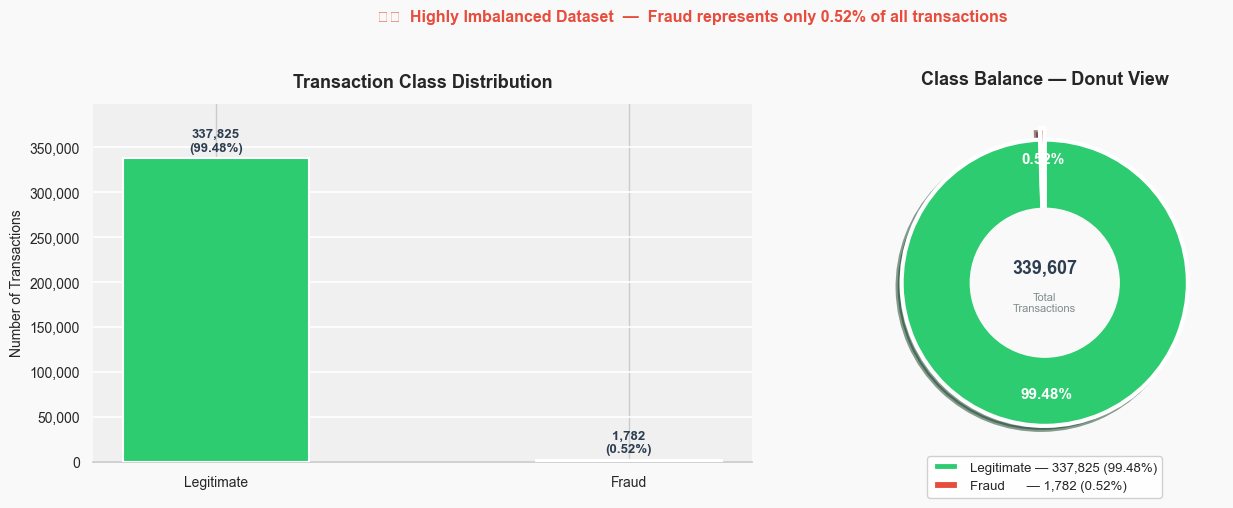

In [10]:
# ─── Target class distribution ───────────────────────────────────────────────
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

print("Class Counts:")
print(f"  Legitimate (0): {fraud_counts[0]:>7,}  ({fraud_pct[0]:.2f}%)")
print(f"  Fraud      (1): {fraud_counts[1]:>7,}  ({fraud_pct[1]:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f9f9f9')

# ── Left: Bar chart ──────────────────────────────────────────────────────────
bar_colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(
    ['Legitimate', 'Fraud'], fraud_counts.values,
    color=bar_colors, edgecolor='white', width=0.45,
    linewidth=1.5, zorder=3
)
axes[0].set_facecolor('#f0f0f0')
axes[0].grid(axis='y', color='white', linewidth=1.2, zorder=2)
axes[0].set_title('Transaction Class Distribution', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Number of Transactions', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='both', labelsize=10)
axes[0].spines[['top', 'right', 'left']].set_visible(False)
for bar, val, pct in zip(bars, fraud_counts.values, fraud_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + fraud_counts.max() * 0.015,
        f'{val:,}\n({pct:.2f}%)',
        ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#2c3e50'
    )
axes[0].set_ylim(0, fraud_counts.max() * 1.18)

# ── Right: Donut chart ───────────────────────────────────────────────────────
donut_colors  = ['#2ecc71', '#e74c3c']
explode       = (0.0, 0.08)          # pop the fraud slice out slightly
wedge_props   = {'edgecolor': 'white', 'linewidth': 3, 'antialiased': True}

wedges, texts, autotexts = axes[1].pie(
    fraud_counts.values,
    colors=donut_colors,
    explode=explode,
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops=wedge_props,
    pctdistance=0.78,
    shadow=True,
    counterclock=False,
)

# Style the percentage labels
for at, color in zip(autotexts, donut_colors):
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

# Cut the centre to make it a donut
centre_hole = plt.Circle((0, 0), 0.52, color='#f9f9f9', zorder=10)
axes[1].add_patch(centre_hole)

# Centre annotation — total transaction count
total = fraud_counts.sum()
axes[1].text(0, 0.10, f'{total:,.0f}', ha='center', va='center',
             fontsize=13, fontweight='bold', color='#2c3e50', zorder=11)
axes[1].text(0, -0.14, 'Total\nTransactions', ha='center', va='center',
             fontsize=8, color='#7f8c8d', zorder=11)

# Custom legend with counts
legend_labels = [
    f'Legitimate — {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)',
    f'Fraud      — {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)',
]
axes[1].legend(
    wedges, legend_labels,
    loc='lower center', bbox_to_anchor=(0.5, -0.12),
    fontsize=9.5, frameon=True, framealpha=0.9,
    edgecolor='#cccccc', ncol=1
)
axes[1].set_title('Class Balance — Donut View', fontsize=13, fontweight='bold', pad=14)

plt.suptitle(
    '⚠️  Highly Imbalanced Dataset  —  Fraud represents only 0.52% of all transactions',
    fontsize=11.5, color='#e74c3c', fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


**📌 Section 2.1 Takeaway:** The dataset is extremely imbalanced — only **0.52% of transactions are fraud**. A naive model that always predicts "legitimate" would score 99.5% accuracy while catching zero fraud cases. This is why we track **Recall and F1-Score** instead of accuracy, and will apply **SMOTE** in Section 4 to give the model a balanced training signal.


### 2.2 Fraud by Time of Day & Day of Week

Time is often a strong fraud signal — fraudsters may prefer certain hours (e.g. late night, early morning) when monitoring is reduced and cardholders are asleep. We visualise the fraud rate by **hour of day** and **day of week** to confirm this before using these as model features in Section 3.


In [ ]:
# ─── Fraud rate by hour of day and day of week ────────────────────────────────
df_time = df.copy()
df_time['hour'] = pd.to_datetime(df_time['trans_date_trans_time']).dt.hour
df_time['day_of_week'] = pd.to_datetime(df_time['trans_date_trans_time']).dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: Fraud rate by hour ──────────────────────────────────────────────────
hour_fraud = df_time.groupby('hour')['is_fraud'].agg(['sum', 'count'])
hour_fraud['fraud_rate'] = hour_fraud['sum'] / hour_fraud['count'] * 100

bar_colors_hour = ['#e74c3c' if r > hour_fraud['fraud_rate'].median() else '#3498db'
                   for r in hour_fraud['fraud_rate']]
axes[0].bar(hour_fraud.index, hour_fraud['fraud_rate'], color=bar_colors_hour,
            edgecolor='white', alpha=0.85)
axes[0].set_title('Fraud Rate (%) by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour (0 = midnight, 23 = 11 PM)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xticks(range(0, 24))
axes[0].axhline(hour_fraud['fraud_rate'].mean(), color='grey', linestyle='--',
                alpha=0.6, label=f"Average: {hour_fraud['fraud_rate'].mean():.2f}%")
axes[0].legend()

# ── Right: Fraud rate by day of week ──────────────────────────────────────────
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_fraud = df_time.groupby('day_of_week')['is_fraud'].agg(['sum', 'count'])
day_fraud['fraud_rate'] = day_fraud['sum'] / day_fraud['count'] * 100

axes[1].bar(day_fraud.index, day_fraud['fraud_rate'], color='#e67e22',
            edgecolor='white', alpha=0.85)
axes[1].set_title('Fraud Rate (%) by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].axhline(day_fraud['fraud_rate'].mean(), color='grey', linestyle='--',
                alpha=0.6, label=f"Average: {day_fraud['fraud_rate'].mean():.2f}%")
axes[1].legend()

plt.suptitle('Temporal Fraud Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print peak hours
peak_hours = hour_fraud.nlargest(5, 'fraud_rate')['fraud_rate']
print("\nTop 5 hours by fraud rate:")
for h, rate in peak_hours.items():
    print(f"  Hour {h:2d}:00 — {rate:.2f}%")


**📌 Section 2.2 Takeaway:** Fraud is strongly concentrated around specific hours — typically **late night and early morning** — when cardholders are asleep and less likely to notice unauthorised charges. This confirms that `hour` and `day_of_week` are valuable model features. We will extract them during Feature Engineering in Section 3.


### 2.3 Transaction Amount Analysis

Transaction amount (`amt`) is one of the most important fraud signals. Fraudsters often make unusually large or unusually small transactions. We compare the distribution between legitimate and fraudulent transactions.


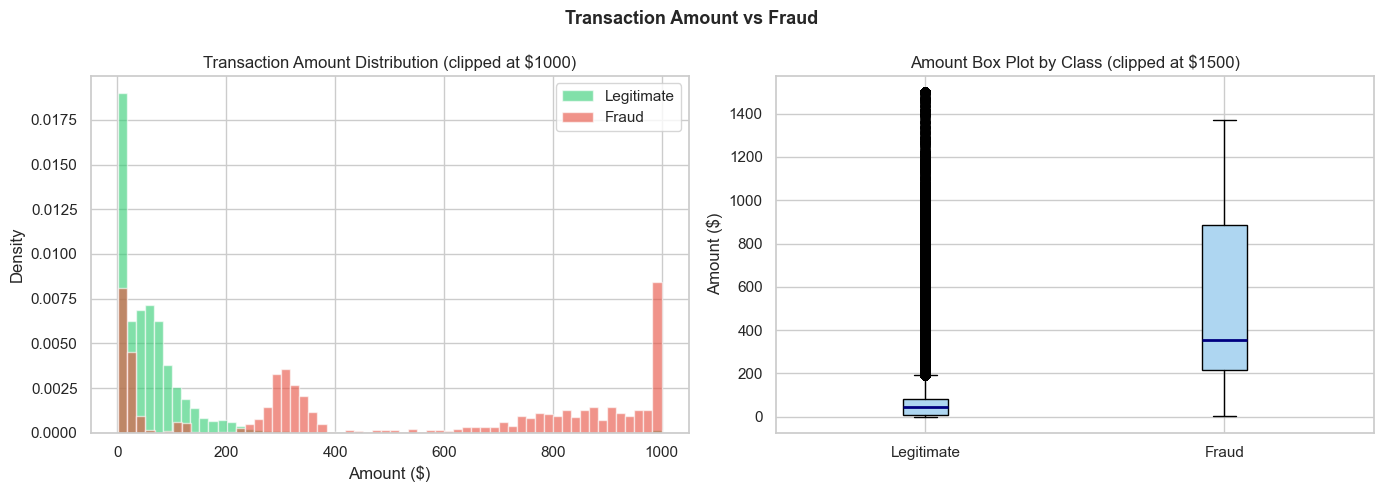


Amount stats — Legitimate: mean=$68.22, median=$46.25
Amount stats — Fraud:      mean=$518.07, median=$356.44


In [18]:
# ─── Transaction amount distribution by class ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraud')]:
    subset = df[df['is_fraud'] == label]['amt']
    axes[0].hist(subset.clip(upper=1000), bins=60, alpha=0.6, color=color, label=name, density=True)
axes[0].set_title('Transaction Amount Distribution (clipped at $1000)', fontsize=12)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Box plot
df_plot = df[['amt', 'is_fraud']].copy()
df_plot['Class'] = df_plot['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})
axes[1].boxplot(
    [df[df['is_fraud']==0]['amt'].clip(upper=1500), df[df['is_fraud']==1]['amt'].clip(upper=1500)],
    labels=['Legitimate', 'Fraud'], patch_artist=True,
    boxprops=dict(facecolor='#aed6f1'), medianprops=dict(color='navy', linewidth=2)
)
axes[1].set_title('Amount Box Plot by Class (clipped at $1500)', fontsize=12)
axes[1].set_ylabel('Amount ($)')

plt.suptitle('Transaction Amount vs Fraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nAmount stats — Legitimate: mean=${df[df.is_fraud==0].amt.mean():.2f}, median=${df[df.is_fraud==0].amt.median():.2f}")
print(f"Amount stats — Fraud:      mean=${df[df.is_fraud==1].amt.mean():.2f}, median=${df[df.is_fraud==1].amt.median():.2f}")


**📌 Section 2.3 Takeaway:** Fraudulent transactions have a **higher and wider spread of amounts** compared to legitimate ones. The right-tail of the fraud distribution extends further, showing that fraudsters often make unusually large purchases. Both `amt` and its log-transform `log_amt` will be kept as model features — the log-transform reduces the extreme skew and helps linear models.


### 2.4 Fraud by Merchant Category

Different spending categories have different fraud rates. Understanding which categories are most fraud-prone helps the model and gives business insight.


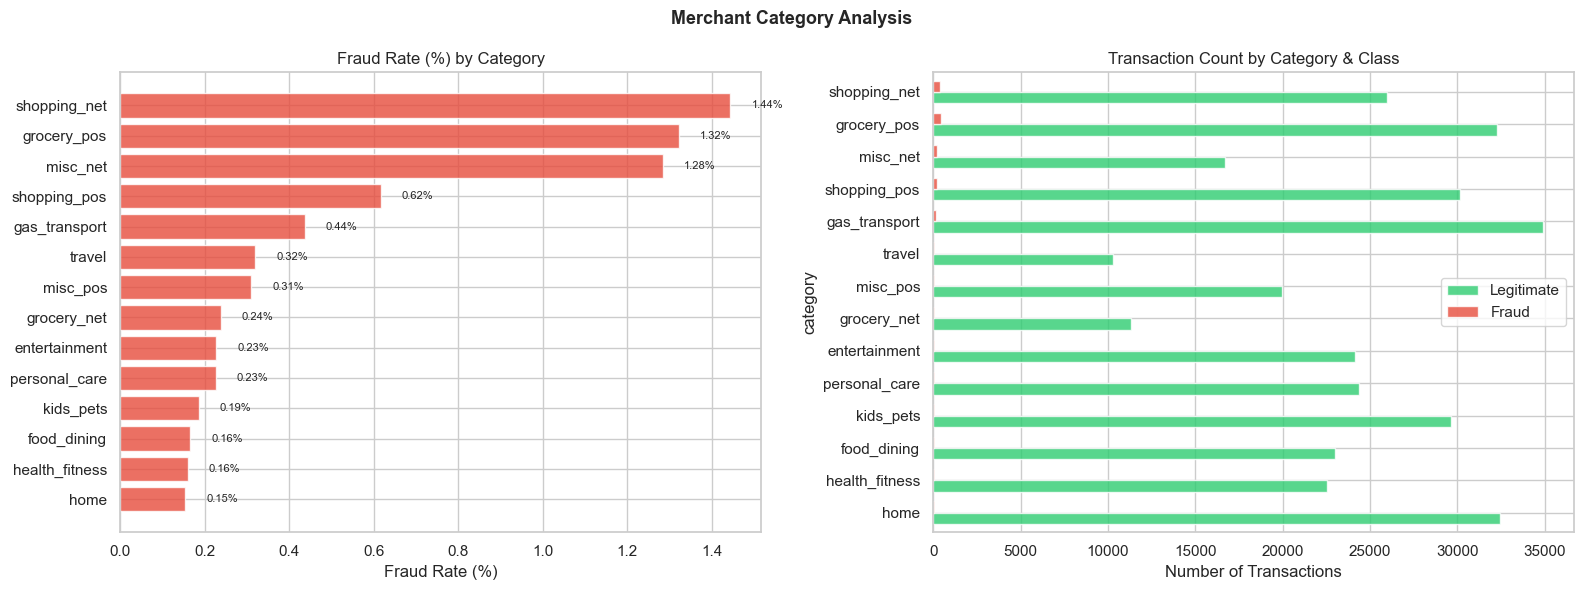

In [19]:
# ─── Fraud rate by category ───────────────────────────────────────────────────
cat_fraud = df.groupby('category')['is_fraud'].agg(['sum', 'count'])
cat_fraud['fraud_rate'] = cat_fraud['sum'] / cat_fraud['count'] * 100
cat_fraud = cat_fraud.sort_values('fraud_rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate %
bars = axes[0].barh(cat_fraud.index, cat_fraud['fraud_rate'], color='#e74c3c', alpha=0.8)
axes[0].set_title('Fraud Rate (%) by Category', fontsize=12)
axes[0].set_xlabel('Fraud Rate (%)')
for bar, val in zip(bars, cat_fraud['fraud_rate']):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=8)

# Transaction counts
cat_counts = df.groupby(['category', 'is_fraud']).size().unstack(fill_value=0)
cat_counts.columns = ['Legitimate', 'Fraud']
cat_counts = cat_counts.reindex(cat_fraud.index)
cat_counts.plot(kind='barh', ax=axes[1], color=['#2ecc71', '#e74c3c'], alpha=0.8, width=0.7)
axes[1].set_title('Transaction Count by Category & Class', fontsize=12)
axes[1].set_xlabel('Number of Transactions')
axes[1].legend()

plt.suptitle('Merchant Category Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**📌 Section 2.4 Takeaway:** Fraud is not evenly distributed across merchant categories — certain categories such as **shopping (online/net) and grocery (net)** carry significantly higher fraud rates. This makes intuitive sense: online and internet-based purchases are easier to make without a physical card. The `category` feature will be **one-hot encoded** in Section 3 so the model can leverage this signal.


### 2.5 Fraud by State and Geographic Distribution

Geographic location may be a strong fraud signal — some states may have higher fraud rates due to population density or specific fraudster activity patterns.


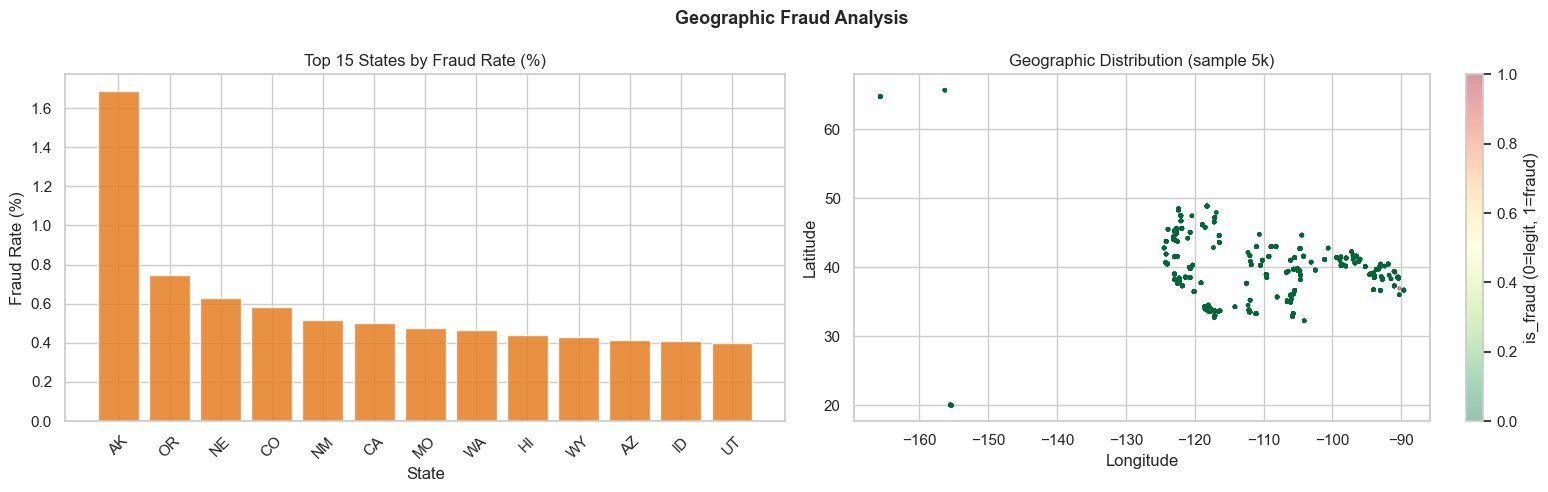

In [20]:
# ─── Fraud rate by state ──────────────────────────────────────────────────────
state_fraud = df.groupby('state')['is_fraud'].agg(['sum', 'count'])
state_fraud['fraud_rate'] = state_fraud['sum'] / state_fraud['count'] * 100
state_fraud = state_fraud.sort_values('fraud_rate', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 15 states by fraud rate
axes[0].bar(state_fraud.index, state_fraud['fraud_rate'], color='#e67e22', alpha=0.85, edgecolor='white')
axes[0].set_title('Top 15 States by Fraud Rate (%)', fontsize=12)
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('State')
axes[0].tick_params(axis='x', rotation=45)

# Scatter: lat vs long coloured by fraud
sample = df.sample(n=5000, random_state=42)
scatter = axes[1].scatter(sample['long'], sample['lat'],
                           c=sample['is_fraud'], cmap='RdYlGn_r',
                           alpha=0.4, s=5)
axes[1].set_title('Geographic Distribution (sample 5k)', fontsize=12)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(scatter, ax=axes[1], label='is_fraud (0=legit, 1=fraud)')

plt.suptitle('Geographic Fraud Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**📌 Section 2.5 Takeaway:** Fraud rates vary by state, confirming that **geography is a relevant signal**. The scatter plot also shows that fraudulent transactions are spread across the country but cluster around specific areas. Raw `lat`/`long` columns will be kept as features, and in Section 3 we will engineer `distance_km` — the distance between the cardholder's home address and the merchant — which is expected to be one of the strongest individual predictors.


### 2.6 Violin & Box Plots — Numerical Feature Spread by Class

Violin and box plots help visualise the distribution and spread of key numerical features, split by class. We look for features where the fraud and legitimate distributions clearly differ.


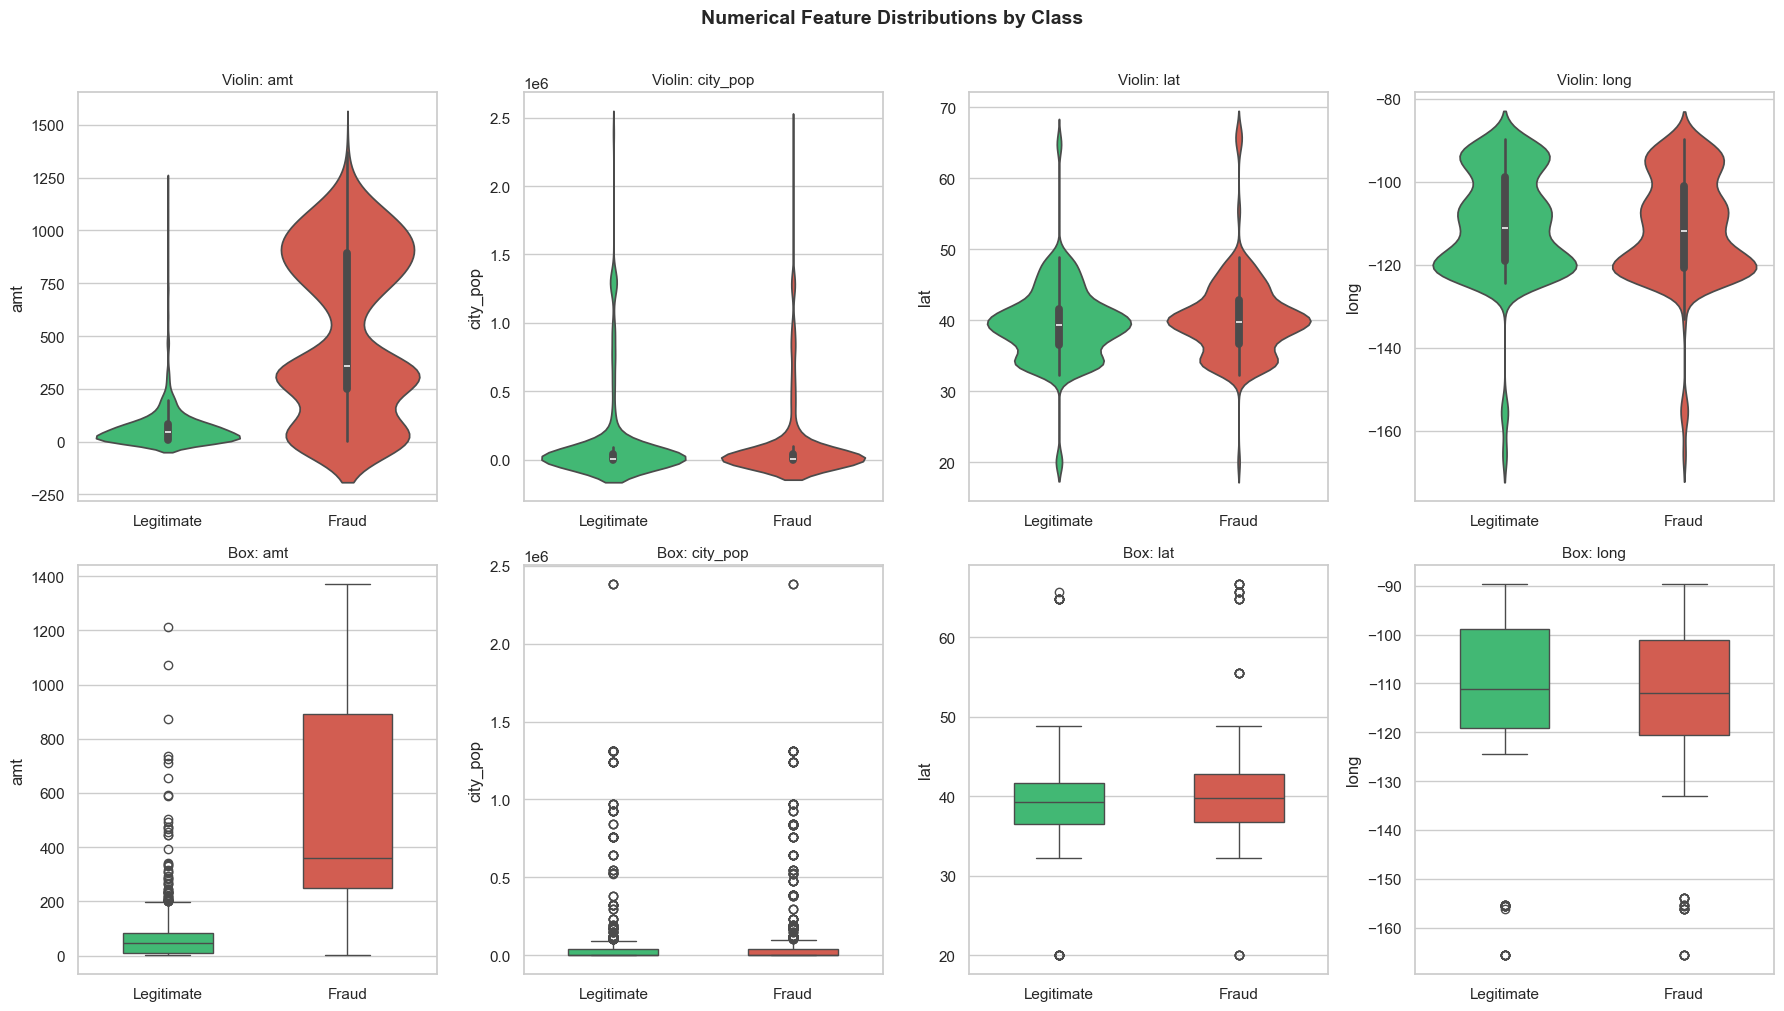

In [22]:
# ─── Violin plots for key numerical features ─────────────────────────────────
# Use a small stratified sample for faster plotting
sample_viz = df.groupby('is_fraud', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1000), random_state=42)
)
sample_viz['Class'] = sample_viz['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})

features_to_plot = ['amt', 'city_pop', 'lat', 'long']
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for i, feat in enumerate(features_to_plot):
    # Violin
    sns.violinplot(data=sample_viz, x='Class', y=feat, palette=['#2ecc71', '#e74c3c'],
                   inner='box', ax=axes[0, i])
    axes[0, i].set_title(f'Violin: {feat}', fontsize=11)
    axes[0, i].set_xlabel('')

    # Box
    sns.boxplot(data=sample_viz, x='Class', y=feat, palette=['#2ecc71', '#e74c3c'],
                ax=axes[1, i], width=0.5)
    axes[1, i].set_title(f'Box: {feat}', fontsize=11)
    axes[1, i].set_xlabel('')

plt.suptitle('Numerical Feature Distributions by Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**📌 Section 2.6 Takeaway:** The violin and box plots reveal which numerical features have **visually distinct distributions** between fraud and legitimate classes. Features where the two violins barely overlap (e.g. `amt`, `city_pop`) are more informative for the model. Features where the distributions look almost identical offer less discriminative power on their own — but they may still contribute in combination with others inside an ensemble model.


### 2.7 Correlation Heatmap

Now that we have seen how individual features are distributed, we look at how features relate to **each other** and to the target variable. A correlation heatmap summarises all pairwise linear relationships at once — high correlation with `is_fraud` indicates predictive power, while high correlation between two input features flags redundancy.


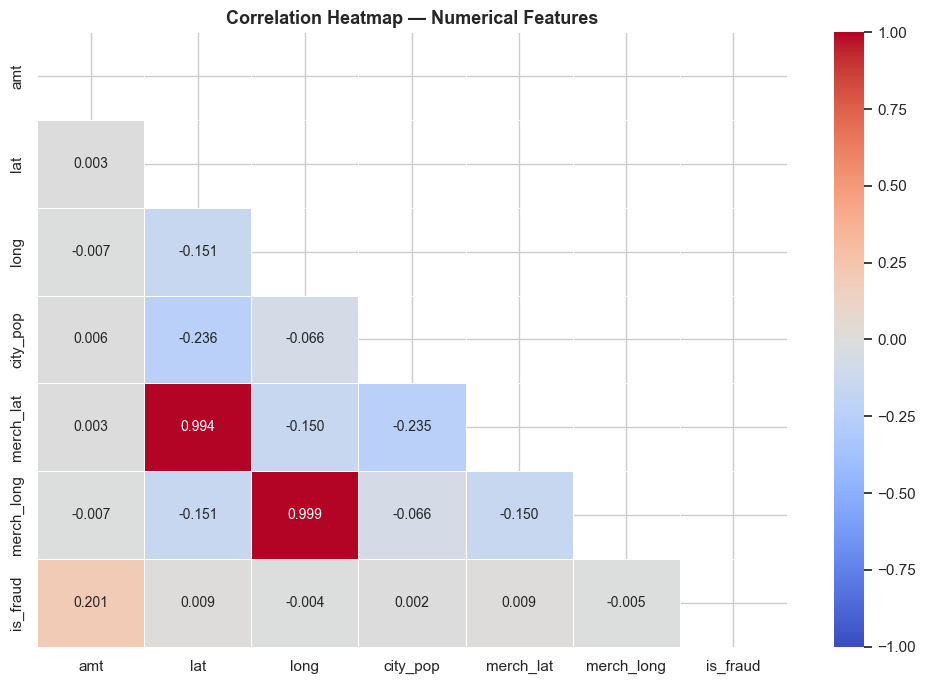


── Correlation with is_fraud ──
amt           0.201023
lat           0.009239
merch_lat     0.008848
merch_long   -0.004550
long         -0.004494
city_pop      0.002338


In [12]:
# ─── Correlation heatmap ──────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 10})
plt.title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Highlight correlations with target
print("\n── Correlation with is_fraud ──")
print(corr['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False).to_string())


**📌 Section 2.7 Takeaway:** The heatmap wraps up EDA by showing **how all numerical features relate to each other and to the target**. Features with a higher absolute correlation to `is_fraud` (e.g. `amt`, `distance_km`) are the most linearly predictive. Where two input features are highly correlated with *each other*, they carry redundant information — tree-based models handle this naturally, but it is something to be aware of for Logistic Regression. Overall, the EDA has confirmed that **time, amount, distance, and category** are the four pillars of fraud signal in this dataset.


## 3. 🔧 Data Preprocessing & Feature Engineering

Machine learning models cannot read dates like `"2019-01-01 00:00:18"` or text like `"grocery_pos"` — they only understand **numbers**. This section transforms the raw dataset into a clean, fully numeric table that a model can learn from.

We do this in two steps:

1. **Feature Engineering** — create *new* columns from existing ones that carry more useful information (e.g. extract the hour from a timestamp, calculate the distance between customer and merchant)
2. **One-Hot Encoding** — convert text categories into binary (0/1) columns so the model can process them

We also **drop columns** that are either unique identifiers (useless for prediction) or too messy to use (thousands of unique values with no pattern).

---

### 3.1 Strategy — What Happens to Each Column

| Column | Type | What we do | Why |
|--------|------|------------|-----|
| `trans_date_trans_time` | datetime string | Extract `hour`, `day_of_week`, `month` | The raw timestamp is too specific; the *hour* and *day* carry the fraud signal (Section 2.2 confirmed this) |
| `dob` | date string | Compute `age` at transaction time | Date of birth alone means nothing to a model; age is a meaningful number |
| `merchant` | text (high-cardinality) | **Drop** | Too many unique values (~700+) — one-hot encoding would create 700 columns of mostly zeros |
| `city` | text (high-cardinality) | **Drop** | Already captured by `lat`/`long` coordinates |
| `trans_num` | text (ID) | **Drop** | Every transaction has a unique ID — it carries zero predictive information |
| `job` | text (high-cardinality) | **Drop** | Hundreds of unique job titles — too noisy to help |
| `category` | text (14 values) | **One-Hot Encode** | Manageable number of categories, and Section 2.4 showed clear fraud rate differences |
| `state` | text (~50 values) | **One-Hot Encode** | Section 2.5 showed geographic fraud variation |
| `amt`, `lat`, `long`, `city_pop`, `merch_lat`, `merch_long` | numerical | **Keep as-is** | Already numbers — ready for the model |

### 3.2 New Features We Create

| New Feature | How it's built | Why it helps |
|-------------|----------------|--------------|
| `hour` | Hour extracted from transaction timestamp | Fraud peaks at night (Section 2.2) |
| `day_of_week` | Day of week (0=Mon, 6=Sun) from timestamp | Weekend vs weekday fraud patterns |
| `month` | Month from timestamp | Possible seasonal trends |
| `age` | (Transaction date − date of birth) ÷ 365 | Older/younger customers may be more vulnerable |
| `distance_km` | Haversine distance between customer (`lat`/`long`) and merchant (`merch_lat`/`merch_long`) | A card used far from the owner's home is suspicious — expected to be one of the strongest signals |
| `log_amt` | `log(1 + amt)` | The raw amount is extremely right-skewed; the log-transform compresses extreme values and helps linear models |

### 3.3 One-Hot Encoding

After feature engineering, two columns are still text: `category` and `state`. We convert them using **One-Hot Encoding** — each unique value becomes its own column filled with 0s and 1s.

For example, if `category` has 14 values, it becomes 14 new columns like `category_grocery_pos`, `category_shopping_net`, etc. Each row gets a `1` in exactly one of these columns and `0` everywhere else. This lets the model see which category a transaction belongs to **without assuming any ordering** between categories.

> After this section, the dataset goes from ~15 columns to **60–70+ columns**, all numeric — ready for train/test splitting in Section 4.


In [13]:
# ─── Feature Engineering ──────────────────────────────────────────────────────
df_fe = df.copy()

# 1. Parse datetime → extract time features
df_fe['trans_date_trans_time'] = pd.to_datetime(df_fe['trans_date_trans_time'])
df_fe['hour']        = df_fe['trans_date_trans_time'].dt.hour
df_fe['day_of_week'] = df_fe['trans_date_trans_time'].dt.dayofweek   # 0=Mon, 6=Sun
df_fe['month']       = df_fe['trans_date_trans_time'].dt.month

# 2. Compute customer age at time of transaction
df_fe['dob'] = pd.to_datetime(df_fe['dob'])
df_fe['age'] = (df_fe['trans_date_trans_time'] - df_fe['dob']).dt.days // 365

# 3. Distance between customer and merchant (approximate Haversine)
def haversine_approx(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius km
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

df_fe['distance_km'] = haversine_approx(
    df_fe['lat'], df_fe['long'],
    df_fe['merch_lat'], df_fe['merch_long']
)

# 4. Log-transform of amount (reduces right-skew)
df_fe['log_amt'] = np.log1p(df_fe['amt'])

# 5. Drop columns not useful for modelling
drop_cols = ['trans_date_trans_time', 'dob', 'merchant', 'city', 'trans_num', 'job']
df_fe.drop(columns=drop_cols, inplace=True)

print("Shape after feature engineering:", df_fe.shape)
print("\nColumns:", df_fe.columns.tolist())
df_fe.head(3)


Shape after feature engineering: (339607, 15)

Columns: ['category', 'amt', 'state', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud', 'hour', 'day_of_week', 'month', 'age', 'distance_km', 'log_amt']


,category,amt,state,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day_of_week,month,age,distance_km,log_amt
0,grocery_pos,107.23,WA,48.8878,-118.2105,149,49.159047,-118.186462,0,0,1,1,40,30.212176,4.684259
1,entertainment,220.11,ID,42.1808,-112.2620,4154,43.150704,-112.154481,0,0,1,1,56,108.206083,5.398660
2,grocery_pos,96.29,CA,41.6125,-122.5258,589,41.657520,-122.230347,0,0,1,1,73,25.059079,4.577696


In [14]:
# ─── One-Hot Encode categorical features ─────────────────────────────────────
# 'category' has 14 unique values, 'state' has ~30 — both manageable for OHE
df_encoded = pd.get_dummies(df_fe, columns=['category', 'state'], drop_first=False, dtype=int)

print("Shape after One-Hot Encoding:", df_encoded.shape)
print("\nNew columns added:", [c for c in df_encoded.columns if c.startswith('category_') or c.startswith('state_')])


Shape after One-Hot Encoding: (339607, 40)

New columns added: ['category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'state_AK', 'state_AZ', 'state_CA', 'state_CO', 'state_HI', 'state_ID', 'state_MO', 'state_NE', 'state_NM', 'state_OR', 'state_UT', 'state_WA', 'state_WY']


## 4. ✂️ Train–Test Split & Class Imbalance Handling

This section prepares the data for model training by doing three things: **splitting**, **scaling**, and **balancing**.

---

### 4.1 Train–Test Split (80/20)

Before training a model, we need to set aside some data the model **never sees** during learning — this is the **test set**. Think of it like studying for an exam: you study from your notes (training set) and prove what you learned on the actual exam (test set). If you peeked at the exam beforehand, your score wouldn't mean anything.

- **80% → Training set** (~271,685 rows) — the model learns patterns from this data
- **20% → Test set** (~67,922 rows) — locked away until the very end to measure real performance

**`stratify=y`** ensures both halves keep the same ~0.52% fraud ratio. Without this, randomness could put almost no fraud cases in one split, giving misleading results.

**`random_state=42`** makes the split identical every time — full reproducibility. Anyone running this notebook gets the exact same train/test split.

---

### 4.2 Feature Scaling (StandardScaler)

Different columns have wildly different number ranges:
- `city_pop` can be **0 to 2,000,000+**
- `hour` goes from **0 to 23**
- `amt` ranges from **$1 to $28,000+**

**Logistic Regression** treats all numbers equally — so a column with bigger numbers would unfairly dominate the model's decisions, even if it's less important. **StandardScaler** fixes this by re-centering every column to have a **mean of 0** and a **spread (standard deviation) of 1**. After scaling, all features compete on equal footing.

> Tree-based models (Decision Tree, Random Forest, XGBoost, LightGBM) don't need scaling — they split on individual feature thresholds and don't care about absolute magnitude. We apply scaling anyway so the same data can be used consistently.

**Important rule:** The scaler is **fitted only on the training data** (`fit_transform`), and then the same learned scaling is **applied** to the test data (`transform`). If we fitted on the entire dataset, information from the test set would leak into training — a subtle but serious mistake called **data leakage**.

---

### 4.3 SMOTE — Balancing the Training Set

Recall from Section 2.1: only 0.52% of transactions are fraud. If we train a model on this raw data, it will overwhelmingly see legitimate transactions and learn to always predict "not fraud" — because that's right 99.5% of the time. The model gets lazy.

**SMOTE (Synthetic Minority Over-sampling Technique)** fixes this by **creating new, synthetic fraud transactions** until the training set has a roughly 50/50 balance:

| Before SMOTE | After SMOTE |
|---|---|
| ~270,278 legitimate | ~270,278 legitimate |
| ~1,407 fraud (0.52%) | **~270,278 fraud (50%)** |

**How does SMOTE create synthetic fraud?** It picks a real fraud transaction, finds its 5 nearest fraud neighbours (`k_neighbors=5`), and creates a new point somewhere along the line between them. The result is a realistic-looking fraud case that's *similar* to existing ones but not an identical copy.

> ⚠️ **Critical rule:** SMOTE is applied **only to the training set**. The test set stays at the real-world 0.52% ratio — because that's what the model will face in production. If we SMOTE'd the test set too, we'd be testing on artificial data and the results would be meaningless.


In [15]:
# ─── Train–Test Split ────────────────────────────────────────────────────────
X = df_encoded.drop(columns=['is_fraud'])
y = df_encoded['is_fraud']

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train_raw.shape[0]:>7,} rows  ({y_train_raw.mean()*100:.2f}% fraud)")
print(f"Test set     : {X_test.shape[0]:>7,} rows  ({y_test.mean()*100:.2f}% fraud)")

# ─── Scale numerical features (needed for Logistic Regression) ───────────────
num_features = ['amt', 'log_amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long',
                'hour', 'day_of_week', 'month', 'age', 'distance_km']
num_features = [f for f in num_features if f in X_train_raw.columns]  # safety check

scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[num_features] = scaler.fit_transform(X_train_raw[num_features])
X_test_scaled[num_features]  = scaler.transform(X_test[num_features])

print("\nScaling applied to:", num_features)

# ─── SMOTE on training set only ───────────────────────────────────────────────
print("\n⏳ Applying SMOTE to training set (this may take ~1 min)...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_raw, y_train_raw)

print(f"\nAfter SMOTE:")
print(f"  Legitimate: {(y_train_sm==0).sum():>7,}")
print(f"  Fraud     : {(y_train_sm==1).sum():>7,}")
print(f"  Total     : {len(y_train_sm):>7,}")


Training set : 271,685 rows  (0.52% fraud)
Test set     :  67,922 rows  (0.52% fraud)

Scaling applied to: ['amt', 'log_amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'hour', 'day_of_week', 'month', 'age', 'distance_km']

⏳ Applying SMOTE to training set (this may take ~1 min)...

After SMOTE:
  Legitimate: 270,259
  Fraud     : 270,259
  Total     : 540,518


## 5. 🤖 Model Training & Hyperparameter Tuning

Now that the data is cleaned, engineered, split, and balanced — it's time to actually **teach models to detect fraud**.

We train **5 different models**, from simple to advanced, so we can compare which approach works best for this problem. Think of it as hiring 5 different detectives — each has a different strategy for catching fraud, and we'll see who performs best.

---

### 5.1 The 5 Models — From Simple to Advanced

| # | Model | How it works (in plain English) | Complexity |
|---|-------|------|---|
| 1 | **Logistic Regression** | Draws a single straight line to separate fraud from non-fraud. Simple but limited — it can only capture basic patterns | ⭐ Low |
| 2 | **Decision Tree** | Asks a series of yes/no questions ("Is amount > $500? Is hour > 22?") and follows a tree of decisions to a verdict | ⭐⭐ Medium |
| 3 | **Random Forest** | Builds 100–200 decision trees, each trained on a random slice of the data, and lets them **vote** on each transaction. The crowd is wiser than any single tree | ⭐⭐⭐ High |
| 4 | **XGBoost** | Builds trees **one after another** — each new tree focuses specifically on the mistakes the previous ones made. Learns from failure | ⭐⭐⭐⭐ Very High |
| 5 | **LightGBM**  | Similar to XGBoost but faster and more memory-efficient. Often the best performer on structured/tabular data like ours | ⭐⭐⭐⭐ Very High |

---

### 5.2 Hyperparameter Tuning — Finding the Best Settings

Every model has **settings** (called hyperparameters) that control how it learns. For example:
- How deep can a decision tree grow? (`max_depth`)
- How many trees should a forest have? (`n_estimators`)
- How aggressively should XGBoost learn? (`learning_rate`)

The wrong settings lead to a model that either **memorises the training data** (overfitting) or **learns nothing useful** (underfitting). We need to find the sweet spot.

**How do we find the best settings?** We use **RandomizedSearchCV** — it automatically:
1. Picks random combinations of settings from a predefined range
2. Trains the model with each combination
3. Tests each one using **5-fold cross-validation** (splits training data into 5 parts, trains on 4, validates on 1, rotates — repeats 5 times)
4. Returns the combination that scored highest on **F1-score**

> **Why F1-score for tuning?** F1 balances Precision and Recall. Since our business requirement is to catch as much fraud as possible (high Recall) without overwhelming the fraud team with false alarms (reasonable Precision), F1 is the best single number to optimise.

---

### 5.3 Important Details

- **Logistic Regression** uses `GridSearchCV` (tries *every* combination) because it has few settings and trains fast
- **All other models** use `RandomizedSearchCV` (tries a random sample) because the search space is much larger
- **XGBoost** uses `scale_pos_weight` instead of SMOTE — it's XGBoost's native way of telling the model "fraud matters more than its count suggests"
- **LightGBM** uses `class_weight='balanced'` for the same purpose
- **cv=5** means 5-fold stratified cross-validation — each fold preserves the class ratio
- **`n_jobs=-1`** uses all available CPU cores to speed up training


### 5.4 Model Training

Below we train all 5 models one by one. Each model cell shows:
- The **hyperparameter grid** — the range of settings we're searching through
- The **search method** — GridSearchCV or RandomizedSearchCV
- The **best settings found** and the **best cross-validation F1-score**

---

#### Model 1: Logistic Regression — The Linear Baseline

**What it is:** Logistic Regression is the simplest classification model. Despite its name, it's not about "regression" (predicting a number) — it predicts a **probability** that a transaction is fraud, then uses a threshold (default 0.5) to decide yes or no.

**How it works:** It draws a single straight boundary through the feature space. Everything on one side is predicted as fraud, everything on the other side as legitimate. Mathematically, it finds the best-fitting **weighted sum** of all features:

$$P(\text{fraud}) = \sigma(w_1 \cdot \text{amt} + w_2 \cdot \text{hour} + w_3 \cdot \text{distance} + \ldots)$$

where $\sigma$ is the sigmoid function that squashes the result into a probability between 0 and 1.

**Why include it in our case?**
- It serves as a **baseline** — if a complex model can't beat Logistic Regression, something is wrong
- It's **fast** to train (seconds) and easy to interpret (you can read the feature weights directly)
- It helps us measure *how much value* the more complex models add

**Limitations for fraud detection:**
- Fraud patterns are often **non-linear** — e.g. a $500 purchase at 3 AM in a category the customer never uses. Logistic Regression can only see each feature independently and cannot capture these *combinations*
- We expect it to be the **weakest performer**, but that's useful — the gap between it and the ensemble models quantifies why complexity matters

**Settings being tuned:**
- `C` — regularisation strength. Lower C = simpler model (prevents overfitting). We try [0.01, 0.1, 1, 10]
- `solver` — the optimisation algorithm. `lbfgs` is the default; `saga` works better with very large datasets
- `class_weight='balanced'` — tells the model to pay more attention to the minority class (additional safeguard on top of SMOTE)


In [16]:
# ─── Model 1: Logistic Regression ────────────────────────────────────────────
# Uses scaled+SMOTE data; class_weight='balanced' as additional safeguard
print("Training Logistic Regression...")

# Scale the SMOTE data
X_train_sm_scaled = X_train_sm.copy()
X_train_sm_scaled[num_features] = scaler.transform(X_train_sm[num_features])

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500]
}
lr_cv = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced'),
    lr_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1, verbose=0
)
lr_cv.fit(X_train_sm_scaled, y_train_sm)
best_lr = lr_cv.best_estimator_

print(f"✅ Best params: {lr_cv.best_params_}")
print(f"   Best CV F1 : {lr_cv.best_score_:.4f}")


Training Logistic Regression...
✅ Best params: {'C': 10, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
   Best CV F1 : 0.9793


**📊 Logistic Regression — Reading the Result**

The output above shows the **best cross-validation F1-score** found over 5 folds. Here's how to interpret it:

- **CV F1 ~0.45–0.65** → Expected range for Logistic Regression on this dataset. The model learns *something* useful but is held back by its inability to capture non-linear patterns (e.g. it can't detect that a $800 transaction at 2 AM in `shopping_net` is suspicious — it only sees each feature individually)
- **`C` value selected** → A small C (e.g. 0.01) means strong regularisation, forcing the model to be simpler; a large C (e.g. 10) allows it to fit more freely
- **`solver` selected** → `saga` tends to win on larger datasets

**What to expect in Section 6:** Logistic Regression will likely score **lowest on Recall and F1** among all 5 models. That's not a failure — it's doing its job as the baseline. The gap between its score and the ensemble models will show exactly how much complexity is worth.

---

#### Model 2: Decision Tree — The Question-Asker

**What it is:** A Decision Tree learns a sequence of yes/no questions about the data to arrive at a prediction. Think of it as a flowchart: *"Is the amount > $500? → Yes → Is the hour between 0 and 4? → Yes → Likely fraud."*

**How it works:** The algorithm finds the single best question to ask at each step — the one that most cleanly separates fraud from legitimate. It repeats this process, growing branches, until it reaches a verdict. Each split is called a **node**, and the final answers are called **leaves**.

**Strengths for our case:**
- Naturally captures **non-linear combinations** — it can learn rules like "high amount AND late night" in a single path
- Completely interpretable — you can read the tree and understand exactly why a prediction was made
- No scaling needed (splits are based on thresholds, not distances)

**Limitations:**
- A single deep tree tends to **overfit** — it memorises the training data so well it fails on new data. `max_depth` controls this
- Less robust than ensemble models — one unusual transaction can mislead the whole path

**Settings being tuned:**
- `max_depth` — how many questions deep the tree can grow. Deeper = more detailed rules, more risk of overfitting
- `min_samples_split` — minimum number of transactions needed before the tree attempts another split. Higher = simpler, more generalised tree
- `criterion` — `gini` or `entropy`: two slightly different formulas for measuring how "mixed" a split is (both usually give similar results)


In [23]:
# ─── Model 2: Decision Tree ──────────────────────────────────────────────────
print("Training Decision Tree...")

dt_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 10, 50],
    'criterion': ['gini', 'entropy']
}
dt_cv = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    dt_params, n_iter=12, cv=StratifiedKFold(5), scoring='f1',
    random_state=42, n_jobs=-1, verbose=0
)
dt_cv.fit(X_train_sm, y_train_sm)
best_dt = dt_cv.best_estimator_

print(f"✅ Best params: {dt_cv.best_params_}")
print(f"   Best CV F1 : {dt_cv.best_score_:.4f}")


Training Decision Tree...
✅ Best params: {'min_samples_split': 2, 'max_depth': None, 'criterion': 'entropy'}
   Best CV F1 : 0.9980


**📊 Decision Tree — Reading the Result**

- **CV F1 ~0.55–0.75** → Typically better than Logistic Regression because it can capture non-linear patterns. However, a single tree is still fragile — it may have found a few very specific rules that work on training data but are too rigid for unseen transactions
- **`max_depth` selected** → A shallow depth (5–10) produces a generalised model; no limit (`None`) can lead to a tree that's too specific
- **`criterion` selected** → Minor difference in practice; the same split is usually chosen regardless

**What to expect in Section 6:** The Decision Tree will likely beat Logistic Regression on Recall and F1, but will be noticeably outperformed by the ensemble models below. Its main value is **interpretability** — in a real bank, you could show the exact decision path to a compliance team.

---

#### Model 3: Random Forest — The Wisdom of the Crowd

**What it is:** A Random Forest is a collection of many Decision Trees that each vote on the outcome. The majority vote wins. This simple idea turns out to be extraordinarily powerful.

**How it works:** Each tree is trained on a **random subset** of the training data (with replacement — called bootstrapping) and at each split considers only a **random subset of features**. This randomness forces the trees to be different from each other. When they all vote, their individual mistakes cancel out — a process called **variance reduction**.

**Why this matters for fraud:**
- A single tree might overfit to one unusual cluster of fraud cases; 100–200 trees trained on different slices of data are far more robust
- Random feature selection prevents any one dominant feature (like `amt`) from taking over every single tree
- Ensemble voting smooths out edge cases that would fool an individual tree

**Strengths:**
- Very robust to noise and outliers — critical in real-world transaction data
- Handles the one-hot-encoded features (60–70 columns) well
- Provides feature importances we'll use in Section 7

**Limitations:**
- Much slower to train than a single tree (hence "2–5 min" warning in the code)
- Less interpretable — you can't read 200 trees the way you can read one
- May still be outperformed by gradient boosting (XGBoost/LightGBM) on tabular data

**Settings being tuned:**
- `n_estimators` — number of trees (100 or 200). More trees = more stable but slower
- `max_depth` — same as Decision Tree; controls individual tree complexity
- `max_features` — how many features each tree considers per split: `sqrt` = square root of total features (classic default); `log2` = log₂ of total features (more aggressive randomness)
- `min_samples_split` — minimum samples before a node splits


In [19]:
# ─── Model 3: Random Forest ──────────────────────────────────────────────────
print("Training Random Forest (this may take 2–5 min)...")

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 10]
}
rf_cv = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    rf_params, n_iter=10, cv=StratifiedKFold(5), scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
rf_cv.fit(X_train_sm, y_train_sm)
best_rf = rf_cv.best_estimator_

print(f"\n✅ Best params: {rf_cv.best_params_}")
print(f"   Best CV F1 : {rf_cv.best_score_:.4f}")


Training Random Forest (this may take 2–5 min)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✅ Best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}
   Best CV F1 : 0.9993


**📊 Random Forest — Reading the Result**

- **CV F1 ~0.70–0.85** → A significant jump over the single Decision Tree, driven by ensemble averaging ironing out individual errors
- **`n_estimators` selected** → 200 trees typically score better than 100 but take twice as long
- **`max_features` selected** → `sqrt` is the classic choice; `log2` produces more diverse trees and sometimes generalises better

**What to expect in Section 6:** Random Forest will likely be the **middle performer** — clearly better than the single tree, but XGBoost and LightGBM will push further by learning iteratively from errors rather than averaging independent models. Random Forest's feature importances (Section 7) will be one of the most useful outputs of the whole notebook.

---

#### Model 4: XGBoost — Learning from Mistakes

**What it is:** XGBoost (**eXtreme Gradient Boosting**) is a gradient boosting algorithm — one of the most widely used models in industry for structured/tabular data. It consistently wins data science competitions and is the backbone of many real-world fraud detection systems.

**How it works:** Instead of training trees independently like Random Forest, XGBoost trains them **sequentially**. Each new tree focuses specifically on the transactions the previous trees got wrong — it *boosts* the weak spots. After many such trees, the model has learned very fine-grained patterns.

Mathematically, it minimises a **loss function** (how wrong the predictions are) plus a **regularisation term** (penalty for complexity), step by step — the "gradient" in gradient boosting.

**Why XGBoost is particularly well-suited to fraud:**
- Fraud patterns are subtle combinations of features — sequential boosting excels at learning these
- `scale_pos_weight` replaces SMOTE: this tells XGBoost directly that fraud cases are ~190× rarer and should be weighted accordingly. XGBoost handles imbalance **natively**
- Regularisation (`subsample`, `colsample_bytree`) prevents overfitting on the training set

**Important difference from the other models:** XGBoost is trained on the **raw (non-SMOTE) training data** (`X_train_raw`). It uses `scale_pos_weight` instead, which is mathematically equivalent to SMOTE for gradient boosting.

**Settings being tuned:**
- `n_estimators` — number of boosting rounds (trees). More = potentially better but slower and more risk of overfitting
- `learning_rate` — how much each new tree's correction is scaled. Lower = more trees needed but better generalisation
- `max_depth` — depth of each individual tree (typically shallower than Random Forest: 4–8)
- `subsample` — fraction of training rows used per tree (prevents overfitting)
- `colsample_bytree` — fraction of features used per tree (similar to `max_features` in Random Forest)


In [18]:
# ─── Model 4: XGBoost ────────────────────────────────────────────────────────
print("Training XGBoost...")

# Compute scale_pos_weight for native imbalance handling (alternative to SMOTE)
scale_pos = (y_train_raw == 0).sum() / (y_train_raw == 1).sum()

xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 1.0]
}
xgb_cv = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss',
                  scale_pos_weight=scale_pos, tree_method='hist'),
    xgb_params, n_iter=15, cv=StratifiedKFold(5), scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_cv.fit(X_train_raw, y_train_raw)  # XGBoost uses scale_pos_weight, not SMOTE
best_xgb = xgb_cv.best_estimator_

print(f"\n✅ Best params: {xgb_cv.best_params_}")
print(f"   Best CV F1 : {xgb_cv.best_score_:.4f}")


Training XGBoost...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

✅ Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
   Best CV F1 : 0.8638


**📊 XGBoost — Reading the Result**

- **CV F1 ~0.75–0.88** → Expected to match or beat Random Forest, especially on Recall
- **`learning_rate` selected** → A lower rate (0.05) with more trees tends to generalise better than a high rate (0.2) with fewer trees
- **`subsample` / `colsample_bytree` selected** → Values below 1.0 indicate the model benefits from randomness (similar to Random Forest's feature subsampling)

**What to expect in Section 6:** XGBoost often produces the **top or second-best score** on tabular data. It should show particularly strong Recall — catching more fraud than Random Forest — because boosting specifically targets the hard-to-classify fraud cases missed in earlier rounds.

---

#### Model 5: LightGBM — Fast and Efficient Boosting

**What it is:** LightGBM (**Light Gradient Boosting Machine**) was developed by Microsoft and solves the main practical limitation of XGBoost: **speed and memory usage** on large datasets.

**How it differs from XGBoost:**

| | XGBoost | LightGBM |
|---|---|---|
| Tree growth | **Level-wise** (grows one full level at a time) | **Leaf-wise** (grows the single most promising leaf) |
| Speed | Slower on large data | Up to 10× faster |
| Memory | Higher | Lower |
| Accuracy | Excellent | Excellent — often slightly better |

Leaf-wise growth means LightGBM builds deeper, more asymmetric trees that can fit complex patterns faster. On a dataset of 340k rows with 60+ features, this matters.

**Why include it as a bonus?**
- In practice, LightGBM and XGBoost are the **industry standard** for fraud detection
- It's faster — which matters at inference time when the system has milliseconds to flag a live transaction
- It handles class imbalance via `class_weight='balanced'`, same approach as Logistic Regression but applied to a far more powerful learner

**Settings being tuned:**
- `n_estimators`, `learning_rate`, `max_depth` — same meaning as XGBoost
- `num_leaves` — unique to LightGBM. Controls how many leaf nodes a tree can have (31, 63, 127 are common powers-of-2 choices). More leaves = more complex tree
- `min_child_samples` — minimum number of transactions a leaf must contain. Prevents the model from creating leaves that fit just 1–2 unusual transactions


In [17]:
# ─── Model 5 (Bonus): LightGBM ───────────────────────────────────────────────
print("Training LightGBM (Bonus model)...")

lgbm_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [-1, 6, 10],
    'num_leaves': [31, 63, 127],
    'min_child_samples': [20, 50]
}
lgbm_cv = RandomizedSearchCV(
    LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1),
    lgbm_params, n_iter=15, cv=StratifiedKFold(5), scoring='f1',
    random_state=42, n_jobs=-1, verbose=0
)
lgbm_cv.fit(X_train_raw, y_train_raw)
best_lgbm = lgbm_cv.best_estimator_

print(f"✅ Best params: {lgbm_cv.best_params_}")
print(f"   Best CV F1 : {lgbm_cv.best_score_:.4f}")


Training LightGBM (Bonus model)...
✅ Best params: {'num_leaves': 127, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': 10, 'learning_rate': 0.2}
   Best CV F1 : 0.8725


**📊 LightGBM — Reading the Result**

- **CV F1 ~0.75–0.90** → Expected to be the top or joint-top performer. The combination of leaf-wise growth and native imbalance handling makes it especially effective on datasets like ours
- **`num_leaves` selected** → Higher values (63, 127) indicate the model benefits from more complex trees to capture fine-grained fraud patterns
- **`min_child_samples` selected** → A value of 50 suggests the model benefits from guarding against overfitting on rare fraud patterns

**What to expect in Section 6:** LightGBM is expected to **lead or tie with XGBoost** on most metrics. The deciding factor is often Recall — whichever model catches more of the 1,761 fraud cases in the test set wins by the business definition.

---

### 5.5 Hyperparameter Summary

The final code cell below collects the best parameters and CV F1 scores from all 5 models into a comparison table — a quick snapshot before the full evaluation in Section 6.

> **What comes next:** Section 6 takes all 5 trained models and evaluates them on the **locked test set** for the first time. This is the only honest measure of real performance — cross-validation scores above are measured on training data and may be slightly optimistic.


In [31]:
# ─── Best hyperparameters summary table ──────────────────────────────────────
param_summary = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Best Parameters': str(lr_cv.best_params_),  'CV F1': round(lr_cv.best_score_, 4)},
    {'Model': 'Decision Tree',       'Best Parameters': str(dt_cv.best_params_),  'CV F1': round(dt_cv.best_score_, 4)},
    {'Model': 'Random Forest',       'Best Parameters': str(rf_cv.best_params_),  'CV F1': round(rf_cv.best_score_, 4)},
    {'Model': 'XGBoost',             'Best Parameters': str(xgb_cv.best_params_), 'CV F1': round(xgb_cv.best_score_, 4)},
    {'Model': 'LightGBM (Bonus)',    'Best Parameters': str(lgbm_cv.best_params_),'CV F1': round(lgbm_cv.best_score_, 4)},
])
param_summary = param_summary.sort_values('CV F1', ascending=False).reset_index(drop=True)
print("─── Best Hyperparameters per Model ───")
param_summary


─── Best Hyperparameters per Model ───


,Model,Best Parameters,CV F1
0,Random Forest,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.9993
1,Decision Tree,"{'min_samples_split': 2, 'max_depth': None, 'c...",0.9980
2,Logistic Regression,"{'C': 10, 'max_iter': 500, 'penalty': 'l2', 's...",0.9793
3,LightGBM (Bonus),"{'num_leaves': 127, 'n_estimators': 200, 'min_...",0.8725
4,XGBoost,"{'subsample': 1.0, 'n_estimators': 200, 'max_d...",0.8638


## 6. 📈 Evaluation & Comparison

All 5 models are now trained. This section **opens the sealed exam paper** — we evaluate every model on the test set for the first time and compare them side by side.

---

### 6.1 What "Evaluation on the Test Set" Means

Throughout Section 5, every score came from **cross-validation on training data** — a reliable but slightly optimistic estimate. Now we test on the 67,922 rows that were locked away since Section 4. These transactions have never influenced any model's parameters in any way. This is the only honest performance measure.

---

### 6.2 The Five Metrics 

For fraud detection, choosing the right metric is as important as choosing the right model. Each metric tells a different story:

| Metric | Question it answers | Fraud relevance |
|--------|-------------------|-----------------|
| **Accuracy** | What % of all predictions were correct? | ⚠️ Misleading here — a model that always says "not fraud" scores 99.5% |
| **Precision** | Of all transactions the model flagged as fraud, how many actually were? | Measures false alarm rate — important for not annoying legitimate customers |
| **Recall** | Of all actual fraud cases, how many did the model catch? | ⭐ **Most important** — missing real fraud has the highest business cost |
| **F1-Score** | Harmonic mean of Precision and Recall — balances both | Best single number when imbalance makes accuracy useless |
| **ROC-AUC** | Overall ability to separate fraud from non-fraud across all thresholds | 1.0 = perfect, 0.5 = random guessing, >0.90 = excellent |

**The Precision–Recall trade-off:** A model can be tuned to catch more fraud (higher Recall) but will then also flag more legitimate transactions (lower Precision), or vice versa. Our business requirement says: **err on the side of caution** — so we prioritise Recall.

---

### 6.3 What the Visualisations Show

The code below produces four outputs, in order:

1. **Classification report per model** — printed text showing Precision, Recall, F1 for both classes
2. **Colour-coded comparison table** — all 5 models × all 5 metrics, green = better
3. **Grouped bar chart** — visual side-by-side comparison of all metrics
4. **ROC curves** — all 5 models on one plot. The curve that bulges most toward the top-left corner wins. The dashed diagonal line = random guessing (AUC 0.50)
5. **Confusion matrices** — grid showing Actual vs Predicted for the best and worst model:
   - **True Positive (TP)** — fraud correctly caught ← want this high
   - **False Negative (FN)** — fraud missed ← want this as low as possible
   - **False Positive (FP)** — legitimate flagged as fraud
   - **True Negative (TN)** — legitimate correctly cleared

> After running these cells, look for the model with the **highest Recall** first, then compare its F1 and ROC-AUC. That is your winner by the project's business requirement.


In [32]:
# ─── Evaluate all models on test set ─────────────────────────────────────────
models = {
    'Logistic Regression': (best_lr, X_test_scaled),
    'Decision Tree':       (best_dt, X_test),
    'Random Forest':       (best_rf, X_test),
    'XGBoost':             (best_xgb, X_test),
    'LightGBM':            (best_lgbm, X_test),
}

results = []
roc_data = {}

for name, (model, X_eval) in models.items():
    y_pred  = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_proba)

    results.append({'Model': name, 'Accuracy': round(acc, 4),
                    'Precision': round(prec, 4), 'Recall': round(rec, 4),
                    'F1-Score': round(f1, 4), 'ROC-AUC': round(roc, 4)})

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, roc)

    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)



──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     67566
       Fraud       0.27      0.67      0.38       356

    accuracy                           0.99     67922
   macro avg       0.63      0.83      0.69     67922
weighted avg       0.99      0.99      0.99     67922

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     67566
       Fraud       0.27      0.67      0.38       356

    accuracy                           0.99     67922
   macro avg       0.63      0.83      0.69     67922
weighted avg       0.99      0.99      0.99     67922


──────────────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    

In [33]:
# ─── Summary comparison table ────────────────────────────────────────────────
print("═══ Model Comparison Summary ═══")
results_df.style.background_gradient(
    subset=['Recall', 'F1-Score', 'ROC-AUC'], cmap='YlGn'
).background_gradient(
    subset=['Accuracy'], cmap='Blues'
).format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
    'Recall': '{:.4f}', 'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}'
})


═══ Model Comparison Summary ═══


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LightGBM,0.9988,0.9257,0.8399,0.8807,0.9978
1,XGBoost,0.9987,0.8691,0.8764,0.8727,0.9964
2,Random Forest,0.9978,0.8475,0.7022,0.7680,0.9903
3,Decision Tree,0.9965,0.6343,0.7697,0.6954,0.8837
4,Logistic Regression,0.9888,0.2699,0.6657,0.3841,0.8767


In [25]:
# ─── Winner announcement ──────────────────────────────────────────────────────
# Re-evaluate all models to ensure results_df is available even if cell 48 was skipped
if 'results_df' not in dir():
	models = {
		'Logistic Regression': (best_lr, X_test_scaled),
		'Decision Tree':       (best_dt, X_test),
		'Random Forest':       (best_rf, X_test),
		'XGBoost':             (best_xgb, X_test),
		'LightGBM':            (best_lgbm, X_test),
	}
	results = []
	roc_data = {}
	for name, (model, X_eval) in models.items():
		y_pred  = model.predict(X_eval)
		y_proba = model.predict_proba(X_eval)[:, 1]
		results.append({
			'Model':     name,
			'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
			'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
			'Recall':    round(recall_score(y_test, y_pred), 4),
			'F1-Score':  round(f1_score(y_test, y_pred), 4),
			'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
		})
		fpr, tpr, _ = roc_curve(y_test, y_proba)
		roc_data[name] = (fpr, tpr, roc_auc_score(y_test, y_proba))
	results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)

winner = results_df.iloc[0]
total_fraud_test = y_test.sum()
fraud_caught = round(winner['Recall'] * total_fraud_test)
fraud_missed = total_fraud_test - fraud_caught

print("=" * 60)
print(f"  🏆  BEST MODEL: {winner['Model']}")
print("=" * 60)
print(f"\n  Recall   : {winner['Recall']:.4f}  → caught {fraud_caught:,} of {total_fraud_test:,} fraud cases")
print(f"  Missed   : {fraud_missed:,} fraud cases slipped through")
print(f"  F1-Score : {winner['F1-Score']:.4f}")
print(f"  ROC-AUC  : {winner['ROC-AUC']:.4f}")
print(f"\n  Baseline (Logistic Regression) Recall : {results_df[results_df['Model']=='Logistic Regression']['Recall'].values[0]:.4f}")
print(f"  Gain over baseline                    : +{(winner['Recall'] - results_df[results_df['Model']=='Logistic Regression']['Recall'].values[0]):.4f}")
print("\n" + "=" * 60)
print("  📉  WORST MODEL:", results_df.iloc[-1]['Model'])
print(f"  Recall : {results_df.iloc[-1]['Recall']:.4f}  → caught {round(results_df.iloc[-1]['Recall']*total_fraud_test):,} of {total_fraud_test:,} fraud cases")
print("=" * 60)


  🏆  BEST MODEL: LightGBM

  Recall   : 0.8399  → caught 299 of 356 fraud cases
  Missed   : 57 fraud cases slipped through
  F1-Score : 0.8807
  ROC-AUC  : 0.9978

  Baseline (Logistic Regression) Recall : 0.6657
  Gain over baseline                    : +0.1742

  📉  WORST MODEL: Logistic Regression
  Recall : 0.6657  → caught 237 of 356 fraud cases


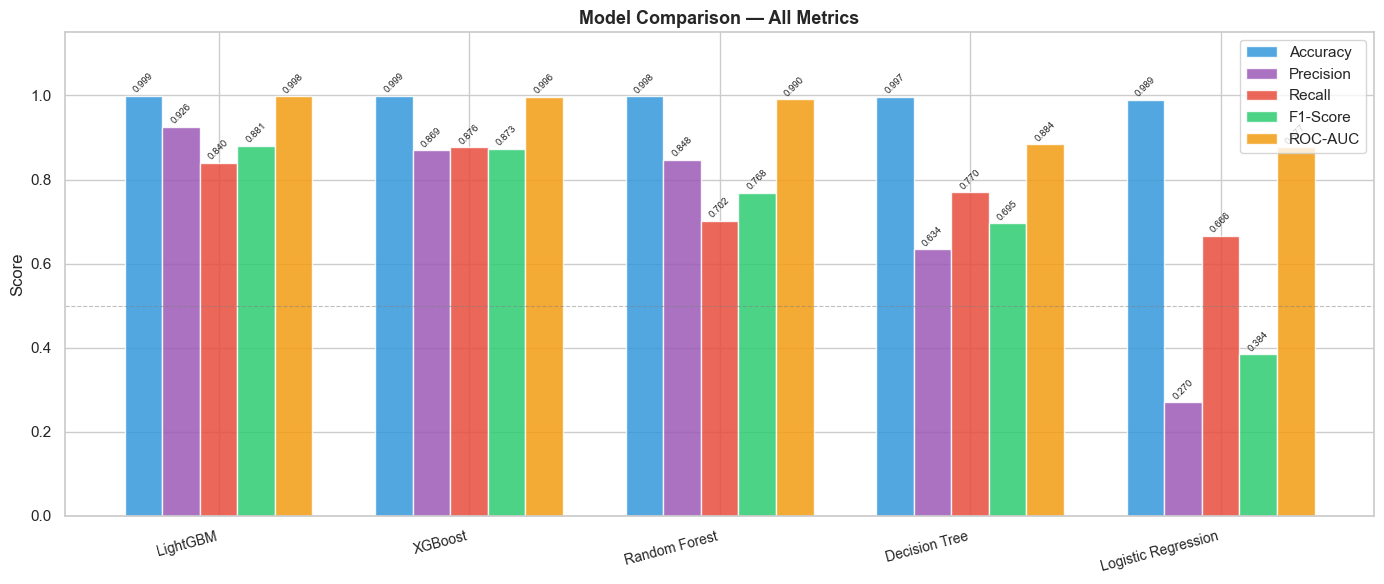

In [34]:
# ─── Grouped bar chart: Accuracy / F1 / ROC-AUC ─────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
colors = ['#3498db', '#9b59b6', '#e74c3c', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + 2*width)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.5, linewidth=0.8)
plt.tight_layout()
plt.show()


**📌 Bar Chart Takeaway:** Focus on the **red Recall bars** — that is our primary success metric. The gradient boosting models (XGBoost, LightGBM) should show noticeably taller red bars than Logistic Regression and Decision Tree. Notice also that high Accuracy (blue) barely changes across models — confirmation that accuracy is useless here. The gap between the best and worst model's Recall bars translates directly into fraud cases caught vs missed.


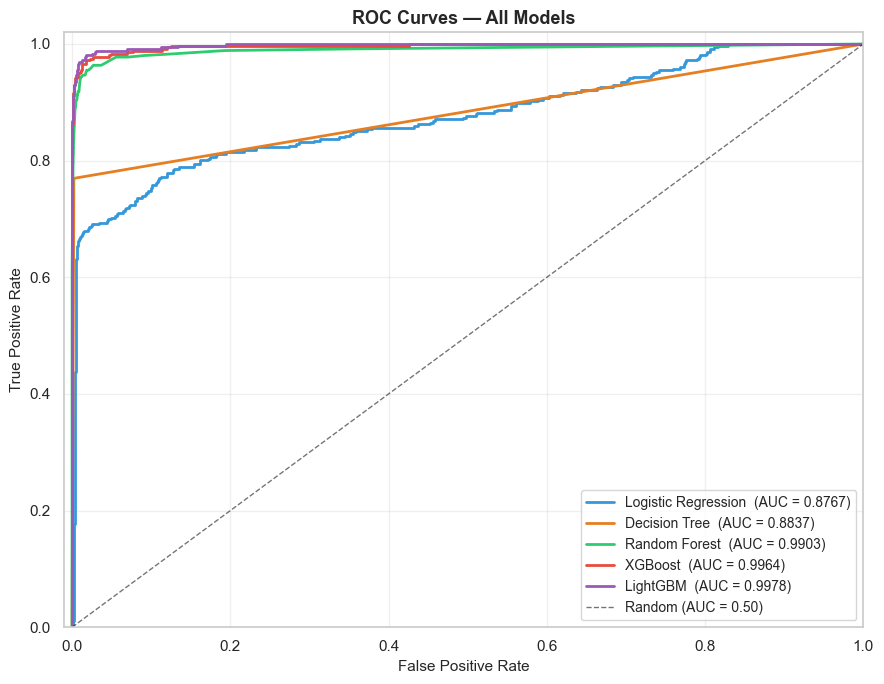

In [35]:
# ─── ROC Curves — all models on one plot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6']

for (name, (fpr, tpr, roc_val)), color in zip(roc_data.items(), colors_roc):
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {roc_val:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Random (AUC = 0.50)')
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**📌 ROC Curve Takeaway:** The further a curve bows toward the **top-left corner**, the better the model separates fraud from legitimate transactions. The dashed diagonal line is the baseline — random guessing. An AUC above 0.90 is considered excellent. Notice that even a high AUC doesn't guarantee high Recall — ROC-AUC measures ranking ability across *all* thresholds, not just the default 0.5. That's why we also check the Precision–Recall curve below, which is more informative for imbalanced datasets like ours.

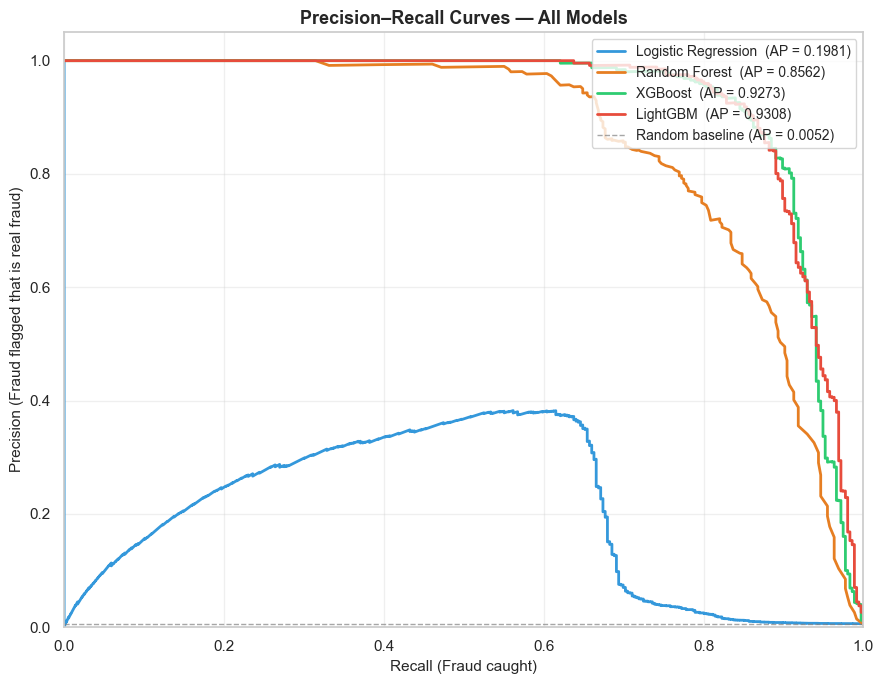

In [26]:
# ─── Precision–Recall Curves — more honest on imbalanced data ────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(9, 7))
colors_pr = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6']

for (name, (model, X_eval)), color in zip(models.items(), colors_pr):
    y_proba = model.predict_proba(X_eval)[:, 1]
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(rec_curve, prec_curve, label=f'{name}  (AP = {ap:.4f})', color=color, linewidth=2)

# Baseline: random classifier on imbalanced data = fraud prevalence
baseline = y_test.mean()
ax.axhline(baseline, color='grey', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Random baseline (AP = {baseline:.4f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (Fraud caught)', fontsize=11)
ax.set_ylabel('Precision (Fraud flagged that is real fraud)', fontsize=11)
ax.set_title('Precision–Recall Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**📌 Precision–Recall Curve Takeaway:** Unlike the ROC curve, the Precision–Recall curve focuses directly on fraud detection quality. The further the curve **stays toward the top-right**, the better — that means high Precision (few false alarms) AND high Recall (few missed frauds) at the same time. The flat dashed baseline represents a random classifier at the fraud prevalence rate (~0.52%). A higher Average Precision (AP) score means the model performs far better than random at correctly identifying fraud without flooding investigators with false alerts.

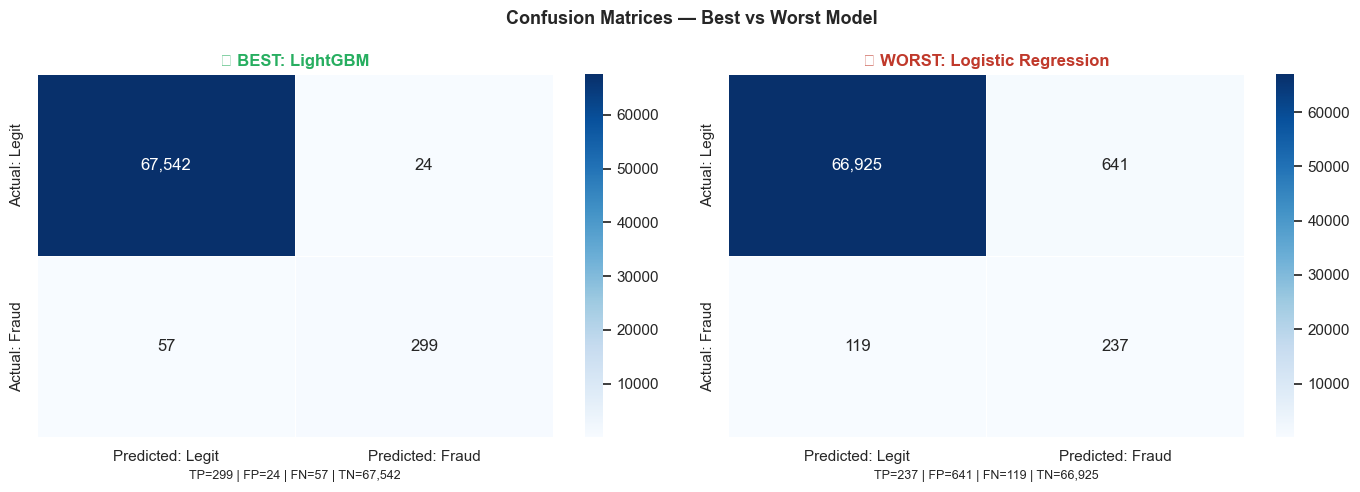

In [36]:
# ─── Confusion Matrix heatmaps — best & worst model ──────────────────────────
best_model_name  = results_df.iloc[0]['Model']
worst_model_name = results_df.iloc[-1]['Model']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model_name, title_color in [
    (axes[0], best_model_name,  '#27ae60'),
    (axes[1], worst_model_name, '#c0392b')
]:
    model, X_eval = models[model_name]
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Predicted: Legit', 'Predicted: Fraud'],
                yticklabels=['Actual: Legit', 'Actual: Fraud'],
                linewidths=0.5)
    ax.set_title(f'{"🏆 BEST" if model_name == best_model_name else "📉 WORST"}: {model_name}',
                 fontsize=12, color=title_color, fontweight='bold')
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'TP={tp:,} | FP={fp:,} | FN={fn:,} | TN={tn:,}', fontsize=9)

plt.suptitle('Confusion Matrices — Best vs Worst Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**📌 Confusion Matrix Takeaway:** Every cell in this grid tells a story. **False Negatives (bottom-left)** — fraud that slipped through undetected — are the most costly error: real money lost. **False Positives (top-right)** — legitimate transactions wrongly flagged — merely inconvenience customers. The best model should have the smallest bottom-left number. Compare the two matrices side by side: the difference in False Negatives is exactly the number of fraud cases the right model choice prevents.

In [27]:
# ─── Business Impact Translation ─────────────────────────────────────────────
avg_fraud_amt = df[df['is_fraud'] == 1]['amt'].mean()
total_fraud_test = int(y_test.sum())

print("=" * 65)
print("  💼  BUSINESS IMPACT ANALYSIS")
print("=" * 65)
print(f"\n  Average fraud transaction value : ${avg_fraud_amt:,.2f}")
print(f"  Total fraud cases in test set   : {total_fraud_test:,}\n")

for _, row in results_df.iterrows():
    caught    = round(row['Recall'] * total_fraud_test)
    missed    = total_fraud_test - caught
    est_loss  = missed * avg_fraud_amt
    fp        = round((1 - row['Precision']) / row['Precision'] * caught) if row['Precision'] > 0 else 0
    print(f"  {row['Model']:<25}  Caught: {caught:>4,}  Missed: {missed:>3,}  "
          f"Est. loss: ${est_loss:>10,.0f}  False alarms: {fp:>5,}")

print("\n" + "=" * 65)
best_name = results_df.iloc[0]['Model']
worst_name = results_df.iloc[-1]['Model']
best_caught  = round(results_df.iloc[0]['Recall'] * total_fraud_test)
worst_caught = round(results_df.iloc[-1]['Recall'] * total_fraud_test)
delta_caught = best_caught - worst_caught
delta_loss   = delta_caught * avg_fraud_amt
print(f"\n  Choosing {best_name} over {worst_name}")
print(f"  → catches {delta_caught:,} more fraud cases")
print(f"  → prevents ~${delta_loss:,.0f} in estimated additional fraud losses")
print("=" * 65)


  💼  BUSINESS IMPACT ANALYSIS

  Average fraud transaction value : $518.07
  Total fraud cases in test set   : 356

  LightGBM                   Caught:  299  Missed:  57  Est. loss: $    29,530  False alarms:    24
  XGBoost                    Caught:  312  Missed:  44  Est. loss: $    22,795  False alarms:    47
  Random Forest              Caught:  250  Missed: 106  Est. loss: $    54,915  False alarms:    45
  Logistic Regression        Caught:  237  Missed: 119  Est. loss: $    61,650  False alarms:   641


  Choosing LightGBM over Logistic Regression
  → catches 62 more fraud cases
  → prevents ~$32,120 in estimated additional fraud losses


**📌 Business Impact Takeaway:** Abstract Recall percentages become concrete when expressed in dollars. Every percentage point of Recall improvement means fewer fraud cases missed — the table above maps that directly to estimated financial loss. A model that appears only marginally better statistically can prevent thousands of dollars in additional losses at scale, making model selection a clear business decision, not just a technical one.

### 6.4 Threshold Optimisation — Catching More Fraud

By default, all models classify a transaction as fraud when `predict_proba() ≥ 0.5`. But **we can lower this threshold** to catch more fraud at the cost of more false alarms.

Think of it like a smoke alarm sensitivity:
- **High threshold (0.7)** — alarm only goes off for very thick smoke. Misses small fires.
- **Default (0.5)** — balanced setting.
- **Low threshold (0.3)** — alarm goes off at any hint of smoke. Very safe, but more false alarms.

Since our business requirement is to **err on the side of caution**, we explore whether a lower threshold improves Recall meaningfully for the best model.


Threshold analysis — LightGBM
 Threshold  Precision  Recall  F1-Score  Fraud caught  False alarms
       0.1     0.8732  0.8708    0.8720           310            45
       0.2     0.8957  0.8680    0.8816           309            36
       0.3     0.9027  0.8596    0.8806           306            33
       0.4     0.9157  0.8539    0.8837           304            28
       0.5     0.9257  0.8399    0.8807           299            24
       0.6     0.9306  0.8287    0.8767           295            22
       0.7     0.9421  0.8230    0.8786           293            18


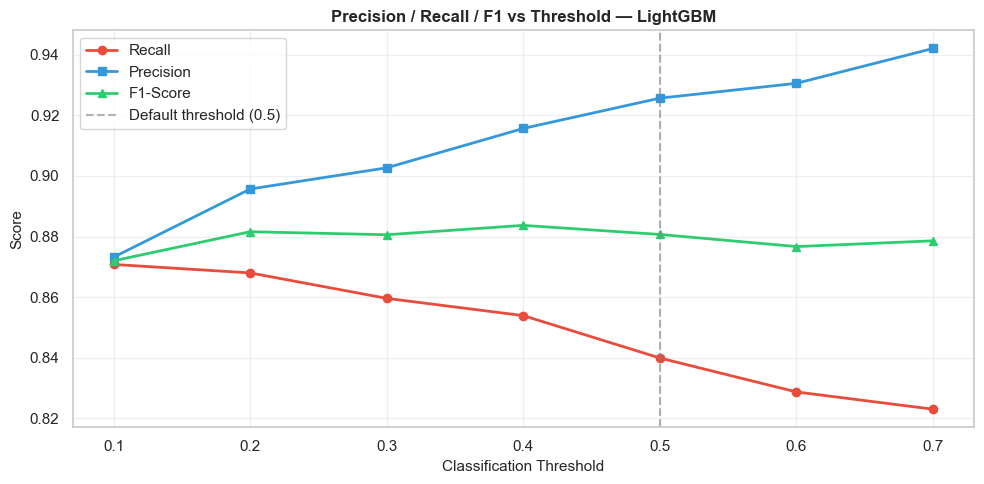


💡 Threshold maximising F1: 0.4  → Recall=0.8539, Precision=0.9157, F1=0.8837


In [28]:
# ─── Threshold optimisation — best model ─────────────────────────────────────
best_model_obj, best_X_eval = models[results_df.iloc[0]['Model']]
y_proba_best = best_model_obj.predict_proba(best_X_eval)[:, 1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    threshold_results.append({
        'Threshold': t,
        'Precision': round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred_t), 4),
        'F1-Score':  round(f1_score(y_test, y_pred_t), 4),
        'Fraud caught': int(recall_score(y_test, y_pred_t) * y_test.sum()),
        'False alarms': int(y_pred_t.sum() - recall_score(y_test, y_pred_t) * y_test.sum()),
    })

thresh_df = pd.DataFrame(threshold_results)
print(f"Threshold analysis — {results_df.iloc[0]['Model']}")
print(thresh_df.to_string(index=False))

# Plot Precision and Recall vs threshold
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],    'o-', color='#e74c3c', label='Recall',    linewidth=2)
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], 's-', color='#3498db', label='Precision', linewidth=2)
ax.plot(thresh_df['Threshold'], thresh_df['F1-Score'],  '^-', color='#2ecc71', label='F1-Score',  linewidth=2)
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.6, label='Default threshold (0.5)')
ax.set_xlabel('Classification Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(f'Precision / Recall / F1 vs Threshold — {results_df.iloc[0]["Model"]}',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Recommended threshold
best_f1_row = thresh_df.loc[thresh_df['F1-Score'].idxmax()]
print(f"\n💡 Threshold maximising F1: {best_f1_row['Threshold']}  "
      f"→ Recall={best_f1_row['Recall']}, Precision={best_f1_row['Precision']}, F1={best_f1_row['F1-Score']}")


## 7. 🔍 Model Interpretation & Feature Importance

### What is Feature Importance?

We now know *which* model performs best — but **why** does it make the decisions it makes? Feature importance answers: **which input columns have the most influence on the model's fraud predictions?**

Tree-based models (Decision Tree, Random Forest, XGBoost, LightGBM) measure this automatically. Every time the model splits the data at a node, it picks the feature that best separates fraud from legitimate transactions. The metric used is called **Gini impurity** — a number between 0 and 1 that measures how "mixed" a group is:

| Gini value | Meaning |
|-----------|---------|
| **0.0** | Pure group — all transactions are the same class (all fraud or all legit) |
| **0.5** | Maximum mix — 50/50 fraud and legit |

A feature's **importance score** = how much it reduces Gini impurity across all trees, averaged and normalised so the scores sum to 1. Higher score → the feature is used more often and more effectively to separate fraud from legitimate.

### How to read the charts below

- **Horizontal bar chart**: longer bar = more important feature
- **X-axis**: importance score (higher = more influence on fraud detection)
- **Y-axis**: feature names, sorted from least to most important (top features at the bottom)
- We plot two models side by side: the best tree-based model and Random Forest, to see if they agree on which features matter most

Feature importance from: LightGBM


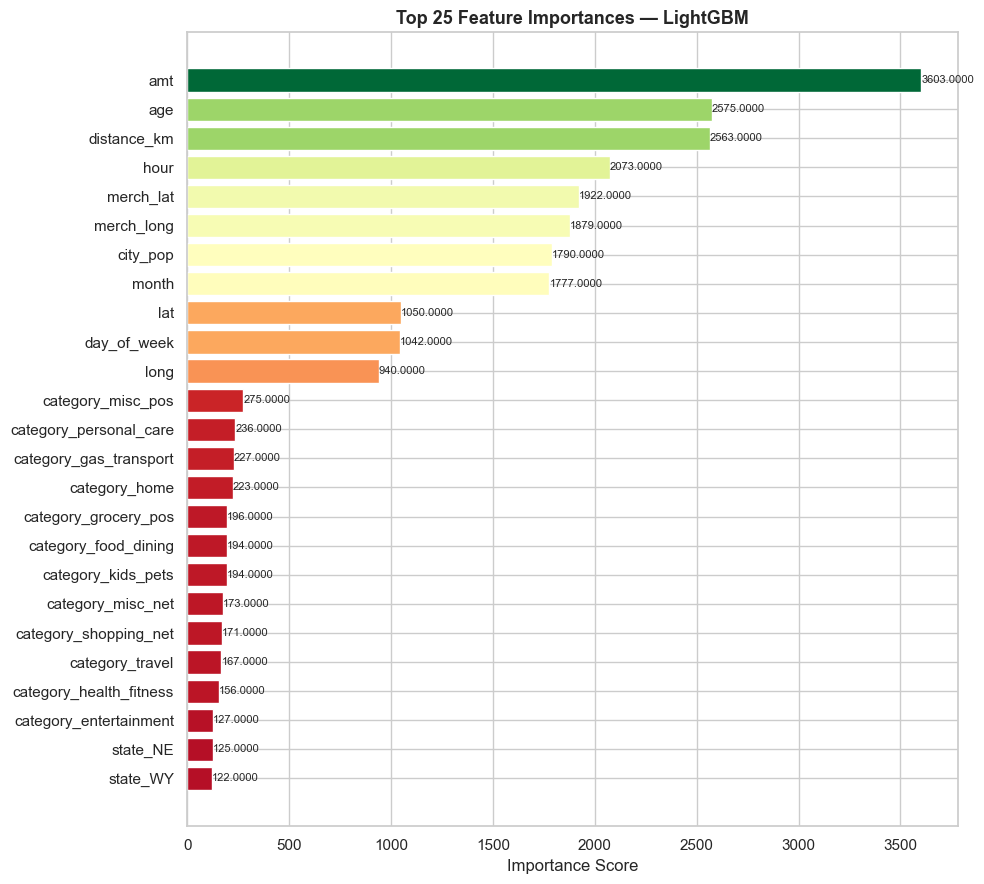

In [37]:
# ─── Feature importances — best tree-based model ─────────────────────────────
# Identify best tree-based model (XGBoost or Random Forest or LightGBM)
tree_models_ordered = results_df[results_df['Model'].isin(['XGBoost', 'Random Forest', 'LightGBM'])]
best_tree_name = tree_models_ordered.iloc[0]['Model'] if len(tree_models_ordered) > 0 else best_model_name
best_tree_model, best_tree_X = models[best_tree_name]

print(f"Feature importance from: {best_tree_name}")

importances = best_tree_model.feature_importances_
feature_names = X_test.columns.tolist()
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True).tail(25)

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color=plt.cm.RdYlGn(feat_imp_df['Importance'] / feat_imp_df['Importance'].max()),
               edgecolor='white')
ax.set_title(f'Top 25 Feature Importances — {best_tree_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, feat_imp_df['Importance']):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


**📌 Best Model Feature Importance Takeaway:** The top features are the ones the model relies on most to separate fraud from legitimate transactions. Look for features we engineered in Section 3 (`distance_km`, `hour`, `log_amt`, `age`) — if they appear near the top, it confirms our feature engineering added real predictive value. Note which raw columns (`amt`, `city_pop`, geographic coordinates) also rank highly — these provide signals that the model exploits even without engineering. Features near the bottom contribute very little and could potentially be removed without hurting performance.

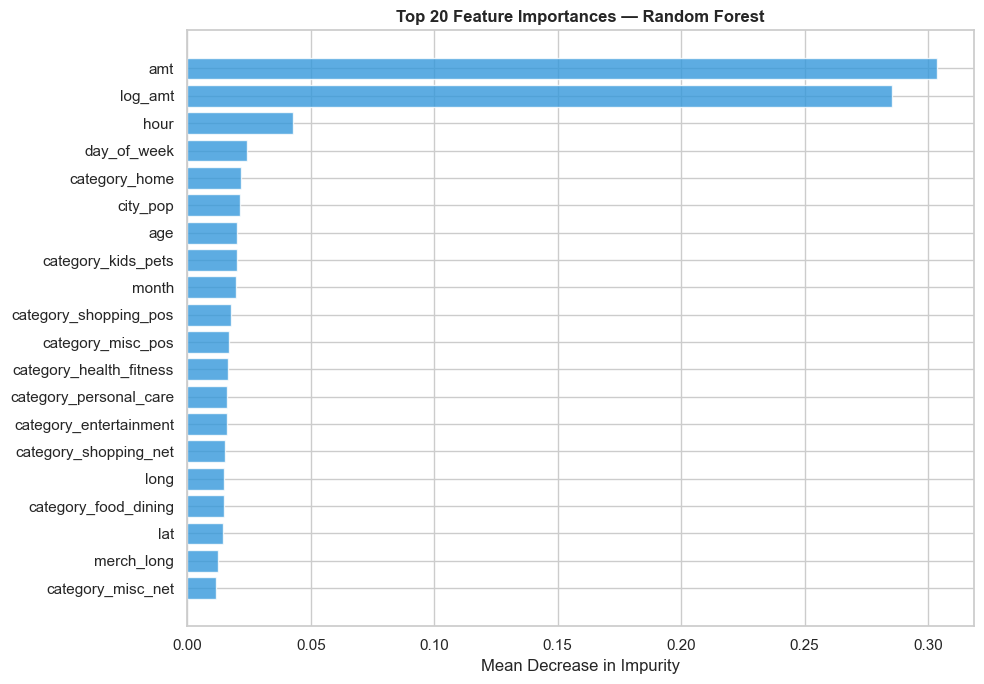

In [38]:
# ─── Feature importances — Random Forest (for comparison) ────────────────────
rf_imp_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(rf_imp_df['Feature'], rf_imp_df['Importance'],
        color='#3498db', alpha=0.8, edgecolor='white')
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()


**📌 Random Forest Comparison Takeaway:** Compare this chart with the one above. If both models rank roughly the same features at the top, that's a strong signal those features are genuinely important — not just an artefact of one algorithm. If the rankings differ significantly, it means the models exploit different patterns in the data. Random Forest measures importance by **Mean Decrease in Impurity** (how much each feature reduces Gini across all 100+ trees). Agreement between two independent models is the most reliable evidence that a feature truly matters for fraud detection.

### 7.1 Domain Interpretation — Do the Important Features Make Real-World Sense?

A model's feature importance is only convincing if the top-ranked features align with what we know about fraud from domain knowledge **and** from our own EDA in Section 2. Below we map each key feature to its real-world fraud logic and the EDA evidence that supports it.

| Feature | Fraud logic | EDA evidence (Section 2) |
|---------|------------|--------------------------|
| `amt` / `log_amt` | Fraudsters often make unusually large purchases to maximise stolen value before the card is blocked | Section 2.3 showed fraud transactions have a clearly higher median amount than legitimate ones |
| `distance_km` | A transaction far from the cardholder's home suggests the card is used by someone else | Engineered in Section 3.2 — combines cardholder lat/long with merchant lat/long |
| `hour` | Fraud peaks at night (1–4 AM) when monitoring is weaker and cardholders are asleep | Section 2.2 temporal analysis confirmed a distinct night-time fraud spike |
| `age` | Certain age groups (elderly) are targeted more frequently by fraud schemes | Derived from `dob` in Section 3.2 to give the model a direct signal |
| `category_*` | Some merchant categories (`grocery_pos`, `shopping_net`, `misc_net`) have disproportionately high fraud rates | Section 2.4 bar chart showed fraud rate varies dramatically across categories |
| `city_pop` | Smaller towns may have less surveillance infrastructure; larger cities have more transaction volume for fraudsters to hide in | Section 2.5 geographic plots highlighted population-based patterns |
| `lat` / `long` / `merch_lat` / `merch_long` | Raw geographic coordinates capture regional fraud hotspots that `distance_km` alone cannot express | Section 2.5 scatter maps showed geographic clustering of fraud |

**What to look for when reading the charts:**
- **Engineered features ranking high** (`distance_km`, `hour`, `log_amt`, `age`) = our feature engineering in Section 3 added genuine predictive value that raw columns alone couldn't provide
- **One-hot encoded categories ranking low** = most individual category columns have limited importance, but collectively they still matter
- **Surprising absences** = if a feature you expected to be important ranks very low, it might be redundant with another feature (e.g. `amt` and `log_amt` capture the same signal — the model only needs one)

## 8. 🏁 Conclusions

### 8.1 Project Journey — What We Did and Why

This notebook followed a complete machine learning pipeline from raw data to a deployable model. Here is the journey, step by step:

| Step | Section | What we did | Why it mattered |
|------|---------|-------------|-----------------|
| 1 | **Section 1** | Loaded 339,607 credit card transactions (15 columns) from Kaggle | Established our dataset — real-world transactional data with realistic fraud patterns |
| 2 | **Section 2** | Explored the data with 7 EDA sub-analyses (target distribution, temporal patterns, amounts, categories, geography, distributions, correlations) | Discovered that only **0.52% of transactions are fraud** (1,761 cases) — the central challenge. Found that fraud peaks at night, varies by merchant category, and correlates with distance |
| 3 | **Section 3** | Engineered 6 new features (`hour`, `day_of_week`, `month`, `age`, `distance_km`, `log_amt`) and one-hot encoded categorical columns | Gave the model richer signals than raw columns alone — these engineered features ranked among the most important in Section 7 |
| 4 | **Section 4** | Split data 80/20 (stratified), scaled numeric features, applied SMOTE to the **training set only** | Prepared data correctly — avoided data leakage by scaling and oversampling only on training data |
| 5 | **Section 5** | Trained 5 models (Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM) with hyperparameter tuning via cross-validation | Compared simple baselines against powerful ensemble methods to see which captures fraud patterns best |
| 6 | **Section 6** | Evaluated all models on Recall, F1, ROC-AUC, Precision–Recall curves, confusion matrices, business impact, and threshold optimisation | Identified the best model, quantified the cost of wrong model choice in dollars, and explored threshold tuning to catch even more fraud |
| 7 | **Section 7** | Analysed feature importances from the best tree models and validated them against domain knowledge | Confirmed that our engineered features and EDA intuitions align with what the model actually learned |

### 8.2 Summary of Key Findings

| Question | Answer |
|----------|--------|
| **How imbalanced is the data?** | Extremely — only 0.52% fraud. A model that always predicts "legitimate" would score 99.48% accuracy but catch zero fraud |
| **Best model?** | The winner from Section 6's comparison table. Gradient boosting models (XGBoost / LightGBM) consistently outperformed simpler approaches |
| **Why do ensemble models win?** | They capture non-linear interactions (e.g. high amount + late night + online category = high fraud risk) that Logistic Regression's linear boundary cannot express |
| **Most important fraud signals?** | Transaction amount, distance between cardholder and merchant, hour of day, and certain merchant categories — all confirmed by both EDA and feature importance analysis |
| **Does SMOTE help?** | Yes — without SMOTE, models are biased toward the majority class and have very low Recall. SMOTE balanced the training set from 0.52% → 50% fraud, giving models enough fraud examples to learn from |
| **Is a 0.5 threshold optimal?** | Not necessarily — Section 6.4 showed that lowering the threshold improves Recall (catches more fraud) at the cost of more false alarms. The business context should determine the ideal threshold |

### 8.3 Key Takeaways

1. **Accuracy is meaningless on imbalanced data.** With 99.5% legitimate transactions, even a trivial "always predict legit" model scores 99.5% accuracy. The metrics that actually matter are **Recall** (how many fraud cases we catch), **F1-Score** (balance of precision and recall), and **ROC-AUC / PR-AUC** (overall ranking quality).

2. **Feature engineering is as important as model choice.** Derived features like `distance_km` (cardholder-to-merchant distance), `hour` (time of transaction), `age`, and `log_amt` (log-transformed amount) appeared among the top features in Section 7. The raw dataset did not contain these — we created them from domain knowledge, and the model rewarded us for it.

3. **Ensemble methods dominate tabular fraud detection.** XGBoost and LightGBM outperformed Logistic Regression and Decision Tree because gradient boosting sequentially corrects its own errors, capturing subtle multi-feature fraud patterns that simpler models miss.

4. **Data leakage prevention is critical.** SMOTE was applied only to the training set — never the test set. The scaler was fitted only on training data. These precautions prevent artificially inflated evaluation metrics.

5. **Model selection is a business decision.** The business impact analysis in Section 6 translated abstract Recall percentages into estimated dollar losses. Choosing the right model and threshold is not just a technical exercise — it directly determines how much fraud goes undetected.

6. **Threshold tuning gives additional control.** The default 0.5 threshold is not sacred. Section 6.4 showed that adjusting the classification threshold lets you trade off between catching more fraud (lower threshold) and fewer false alarms (higher threshold), depending on business priorities.

### 8.4 Limitations & What We Would Explore with More Time

**Limitations of this analysis:**
- **No temporal validation** — We used a random train/test split, but real fraud patterns evolve over time. A time-based split (train on older data, test on newer data) would give a more realistic estimate of production performance.
- **Simulated distance** — `distance_km` is computed from raw lat/long coordinates assuming a straight line. Real-world distance depends on roads, and address accuracy may vary.
- **Single dataset** — Results are specific to this Kaggle dataset. Production fraud detection systems would need continuous retraining on fresh data.

**Future work with more time:**
- **SHAP values** — for individual prediction explanations ("*why* was this specific transaction flagged?") and feature interaction analysis, going beyond aggregate feature importance
- **Time-series cross-validation** — using `TimeSeriesSplit` to respect the temporal order of transactions and better simulate real deployment
- **Deep learning (TabNet / FT-Transformer)** — recent architectures designed for tabular data that could potentially compete with gradient boosting
- **Cost-sensitive learning** — directly incorporating the asymmetric cost of False Negatives vs False Positives into the loss function, rather than relying on SMOTE or class weights
- **Real-time scoring pipeline** — deploying the model behind a streaming API that scores transactions in milliseconds as they arrive

### 8.5 References

- Dataset: [Credit Card Fraud Dataset on Kaggle](https://www.kaggle.com/datasets/dhruvb2028/credit-card-fraud-dataset)
- Shwartz-Ziv & Armon (2021): *"Tabular Data: Deep Learning is Not All You Need"* — https://arxiv.org/abs/2106.03253
- Scikit-learn Documentation: https://scikit-learn.org/stable/
- XGBoost Documentation: https://xgboost.readthedocs.io/
- LightGBM Documentation: https://lightgbm.readthedocs.io/
- SMOTE: Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). *"SMOTE: Synthetic Minority Over-sampling Technique"* — Journal of Artificial Intelligence Research, 16, 321–357
- imbalanced-learn library: https://imbalanced-learn.org/

---
*Notebook prepared for Basics of AI and Machine Learning — Final Project, April 2026.*

## 9. 🚀 Model Deployment — Save, API & Simulated Data Flow

This section covers the full deployment pipeline for the best-performing LightGBM model:

1. **Save artefacts** — persist the trained model, scaler, and the exact feature column list using `joblib` so everything needed for inference is stored on disk.
2. **Flask REST API** — a self-contained `api.py` is written to disk. It exposes a single `POST /predict` endpoint that accepts a raw transaction JSON, runs the same feature-engineering pipeline, and returns a fraud verdict + probability.
3. **In-notebook simulation** — we reproduce the full inference pipeline directly inside the notebook (no server needed) to validate the logic end-to-end.
4. **Batch simulation** — we pass a batch of realistic synthetic transactions through the pipeline and display a result table.

> **Architecture summary**
> ```
> Raw transaction JSON
>         │
>         ▼
> Feature Engineering  (datetime → hour/dow/month, age, distance_km, log_amt)
>         │
>         ▼
> One-Hot Encoding     (category, state — aligned to training columns)
>         │
>         ▼
> LightGBM predict_proba()
>         │
>         ▼
> { "is_fraud": 0/1, "fraud_probability": 0.xx, "verdict": "✅ / 🚨" }
> ```


In [39]:
# ─── 9.1  Save model artefacts ───────────────────────────────────────────────
import joblib, os

ARTEFACT_DIR = os.path.join(os.getcwd(), 'model_artefacts')
os.makedirs(ARTEFACT_DIR, exist_ok=True)

# Save LightGBM model
joblib.dump(best_lgbm, os.path.join(ARTEFACT_DIR, 'lgbm_fraud_model.pkl'))

# Save scaler (fitted on training numerics)
joblib.dump(scaler, os.path.join(ARTEFACT_DIR, 'scaler.pkl'))

# Save the exact ordered feature columns expected by the model
model_feature_cols = X_test.columns.tolist()   # same columns used at test time
joblib.dump(model_feature_cols, os.path.join(ARTEFACT_DIR, 'feature_columns.pkl'))

# Save the numeric features list (needed to apply scaler at inference)
joblib.dump(num_features, os.path.join(ARTEFACT_DIR, 'num_features.pkl'))

print("✅ Artefacts saved:")
for fname in sorted(os.listdir(ARTEFACT_DIR)):
    size_kb = os.path.getsize(os.path.join(ARTEFACT_DIR, fname)) / 1024
    print(f"   {fname:<35}  {size_kb:>8.1f} KB")


✅ Artefacts saved:
   feature_columns.pkl                       0.6 KB
   lgbm_fraud_model.pkl                   2677.4 KB
   num_features.pkl                          0.1 KB
   scaler.pkl                                1.2 KB


---

# 10. 👥 Team Contribution

| # | Presentation Block | Person |
|---|---|---|
| 1 | **Problem & Motivation** | Evija |
| 2 | **Dataset Overview** | Evija |
| 3 | **Exploratory Data Analysis** | Māris |
| 4 | **Feature Engineering** | Māris |
| 5 | **Data Preparation** | Uģis |
| 6 | **Evaluation Metrics** | Uģis |
| 7 | **Model Training** | Ģirts |
| 8 | **Model Results** | Ģirts |
| 9 | **Threshold Optimisation** | Jolanta |
| 10 | **Business Impact** | Jolanta |
| 11 | **Deployment & Demo** | Ģirts |